# Проект "Исследование Solidity смарт контрактов на уязвимости при помощи ML подхода"

**Цель проекта:** 
- Рассмотреть различные методы и способы поиска уязвимостей в смарт контрактах через параметры дизасемблированного байткода;
- Решить задачу бинарной классификации, а именно определить существует ли вообще в исследуемом контракте какая либо уязвимость;
- ~~Решить задачу мультиклассовой классификации, а именно определить какие именно уязвимость есть в контракте и с какой вероятностью;~~
- ~~Сравнить полученный результат с бейзлайн решением (сканеры уязвимостей).~~ - (будет позднее)

**Входные данные:**
- 120608 предварительно исследованных и размеченных смарт контрактов с 9 видами уязвимостей, 36479 из которых - безопасные. https://huggingface.co/datasets/mwritescode/slither-audited-smart-contracts.

**Порядок исследования:**

Работать будем, в первую очередь, со скомпилированным байткодом смарт контрактов, так как по запросу из блокчейна, получить можно только его. Исходный код самих контрактов встречается довольно редко, так как сам по себе явно указывает на все возможные уязвимости и недостатки за счет указания типов и функций. Для байткода:
- Рагрузка и предобработка данных;
- Извлечение evm инструкций из байткода контракта;
- Создание признаков на основе статистик набора инструкций;
- Подбор моделей и их параметров и оценка результата;
- Создание признаков на основе текстовой последовательности инструкций
- Построение итоговой модели и интерпретация полученного результата



In [118]:
%pip install optuna-integration[wandb]

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Импорты

In [6]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
ERROR: Ignored the following versions that require a different python version: 1.3.3 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement contourpy==1.3.3 (from versions: 0.0.1, 0.0.2, 0.0.3, 0.0.4, 0.0.5, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.1.0, 1.1.1rc1, 1.1.1, 1.2.0, 1.2.1rc1, 1.2.1, 1.3.0, 1.3.1, 1.3.2)

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: No matching distribution found for contourpy==1.3.3


In [8]:
%pip install optuna

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import joblib
from joblib import Parallel, delayed
from collections import Counter
from scipy.stats import entropy

from scipy.sparse import vstack, csr_matrix
from collections import defaultdict
import matplotlib.pyplot as plt
import multiprocessing as mp
from tqdm import tqdm
import pandas as pd
import numpy as np
import datetime
import pickle
import optuna
import json
import re


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from pyevmasm import disassemble, disassemble_all
from warnings import filterwarnings
from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True, nb_workers=30)
filterwarnings("ignore")
RANDOM_STATE = 42

INFO: Pandarallel will run on 30 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


## Чтение предобработка данных

Данные сохранены в parquet формате и доступны по ссылке https://huggingface.co/datasets/mwritescode/slither-audited-smart-contracts/tree/main/data/raw

In [2]:
df = pd.DataFrame()
for df_index in range(9):
    df = pd.concat([df, pd.read_parquet(f'datasets/contracts{df_index}.parquet', engine='pyarrow')])

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120608 entries, 0 to 120607
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   contracts    120608 non-null  object
 1   source_code  120608 non-null  object
 2   bytecode     120608 non-null  object
 3   results      120608 non-null  object
dtypes: object(4)
memory usage: 3.7+ MB


,contracts,source_code,bytecode,results
0,006699d34AA3013605d468d2755A2Fe59A16B12B,pragma solidity 0.5.4;\n\ninterface IERC20 {\n...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {""..."
1,00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,pragma solidity 0.6.10;\npragma experimental A...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {""..."
2,010c5322d78c88ca18282b0a072a8913648b3038,pragma solidity 0.6.5;\npragma experimental AB...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {}}"
3,0114622386c1a00686e594c70682d7aa0f8afa29,pragma solidity 0.6.6;\n\nlibrary Address {\n\...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {}}"
4,01A6F6Ac4F5b2564e8C52BA687E7019D0E81E7e8,pragma solidity 0.6.8;\npragma experimental AB...,0x6080604052600436106101665760003560e01c80637d...,"{""success"": true, ""error"": null, ""results"": {""..."


Данные содержат:
- contracts - адрес смарт контракта в блокчейне;
- source_code - исходный Solidity код контракта;
- bytecode - скомпилированный байткод контракта;
- results - отчет сканирования исходного кода контракта сканером уязвимостей slither.

`Примечание`. Разметке сканера slither можем доверять при переопределении лейблов самих контрактов, так как он работал с исходным кодом и поэтому довольно точен в определении уязвимостей.

Явных пропусков в данных нет.


В предобработке:
- Убираем лишние символы для байткода;
- Убираем дубли исходный код + байткод;
- Убираем пустые байткоды;
- Переразмечаем отчет slither в лейблы, согласно маппингу, представленному в репозитории;
- Отбираем 10 процентов датасета, сохраняя соотношение классов в отложенную валидационную выборку.

In [3]:
def get_class_labels(results_json_str):
    try:
        data = json.loads(results_json_str)
        detectors = data.get("results", {}).get("detectors", [])
        labels = []
        for det in detectors:
            check = det.get("check")
            if check and check in mappings:
                label = mappings[check]
                if label != "ignore":
                    labels.append(label)
        unique_labels = list(dict.fromkeys(labels))
        return unique_labels
    except json.JSONDecodeError:
        return []
    
df['bytecode'] = df['bytecode'].apply(lambda x: x[2:])
df = df[df['bytecode'] != '']
print(df.duplicated(subset=['source_code', 'bytecode']).sum())
df.drop_duplicates(subset=['source_code', 'bytecode'], inplace=True)
df.reset_index(drop=True, inplace=True)

with open('datasets/label_mappings.json', 'r') as f:
    mappings = json.load(f)

df['class_labels'] = df['results'].apply(get_class_labels)
df['is_vulnerable'] = (df['class_labels'].apply(len) > 0).astype(int)

3517


In [4]:
display(df['is_vulnerable'].value_counts(normalize=True))
df.head()

1    0.687404
0    0.312596
Name: is_vulnerable, dtype: float64

,contracts,source_code,bytecode,results,class_labels,is_vulnerable
0,006699d34AA3013605d468d2755A2Fe59A16B12B,pragma solidity 0.5.4;\n\ninterface IERC20 {\n...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {""...",[arithmetic],1
1,00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,pragma solidity 0.6.10;\npragma experimental A...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {""...","[arithmetic, other, reentrancy]",1
2,010c5322d78c88ca18282b0a072a8913648b3038,pragma solidity 0.6.5;\npragma experimental AB...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {}}",[],0
3,0114622386c1a00686e594c70682d7aa0f8afa29,pragma solidity 0.6.6;\n\nlibrary Address {\n\...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {}}",[],0
4,01A6F6Ac4F5b2564e8C52BA687E7019D0E81E7e8,pragma solidity 0.6.8;\npragma experimental AB...,6080604052600436106101665760003560e01c80637d53...,"{""success"": true, ""error"": null, ""results"": {""...","[other, arithmetic, reentrancy, unchecked-call...",1


In [5]:
train_df, val_df = train_test_split(df, test_size=0.1, random_state=RANDOM_STATE, stratify=df['is_vulnerable'])

display(train_df['is_vulnerable'].value_counts())
display(val_df['is_vulnerable'].value_counts())

train_df.to_parquet('datasets/train.parquet', engine='pyarrow')
val_df.to_parquet('datasets/val.parquet', engine='pyarrow')

train_df.drop(columns=['contracts', 'source_code', 'results', 'class_labels'], inplace=True)
val_df.drop(columns=['contracts', 'source_code', 'results', 'class_labels'], inplace=True)
del df

1    72196
0    32831
Name: is_vulnerable, dtype: int64

1    8022
0    3648
Name: is_vulnerable, dtype: int64

Исходный датасет удаляем для экономии памяти. Далее работаем с выборками. Для них убираем лишние большие текстовые поля.

## Функции для работы с байткодом

Для исследования байткода мы воспользуемся дизассемблером pyevm, который позволяет развернуть машинный код контракта в список инструкций, которые исполняются в Etherium Virtual Machine.

Дизасемблер разворачивает последовательность байт строки в набор инструкций (python класс - Instruction) с рядом параметров, перечисленных ниже.

### Описание параметров дизасемблированных инструкций
**Значения параметров класса Instruction**

| Атрибут | Значение | Описание и контекст безопасности |
|---------|----------|----------------------------------|
| **`_description`** и **`description`** | `"Get balance of the given account."` | **Описание инструкции**<br>• Проверка баланса контракта/аккаунта<br>• Может влиять на логику выполнения (проверка достаточности баланса) |
| **`_fee`** и **`fee`** | `700` | **Стоимость выполнения в газе**<br>• Высокая стоимость - цель для атак на исчерпание газа<br>• Неправильная оценка газа → непредвиденные затраты |
| **`_long_name`** | `<function>` | **Генератор длинного имени инструкции**<br>• Для детального логирования и анализа потока инструкций |
| **`_name`** и **`name`** | `"BALANCE"` | **Мнемоника инструкции**<br>• Идентификация в байт-коде<br>• Поиск подозрительных инструкций |
| **`_opcode`** и **`opcode`** | `49 (0x31)` | **Числовой код операции**<br>• Анализ опкодов для выявления опасных инструкций |
| **`_operand_size`** и **`operand_size`** | `0` | **Размер операнда**<br>• BALANCE не имеет операндов - данные берутся из стека |
| **`_pc`** и **`pc`** | `19` | **Счетчик команд**<br>• Отслеживание пути выполнения<br>• Выявление уязвимостей в порядке инструкций |
| **`_pops`** и **`pops`** | `1` | **Элементы из стека**<br>• Извлекает адрес аккаунта для проверки баланса |
| **`_pushes`** и **`pushes`** | `1` | **Элементы в стек**<br>• Помещает баланс аккаунта в wei |
| **`bytes`** | `b'1'` | **Байтовое представление**<br>• Сравнение с исходным байт-кодом<br>• Анализ низкоуровневого представления |
| **`group`** | `'Environmental Information'` | **Группа инструкций**<br>• Предоставляет информацию о среде выполнения<br>• Потенциально подвержена манипуляциям майнеров |
| **`is_environmental`** | `True` | **Флаг environmental-инструкции**<br>• Зависит от внешних факторов<br>• Может быть изменена майнерами (временные метки, балансы) |
| **`mnemonic`** | `'BALANCE'` | **Мнемоника**<br>• Аналогично name - идентификация инструкции |
| **`parse_operand`** | `<method>` | **Парсер операндов**<br>• У BALANCE операндов нет → возвращает None |
| **`reads_from_stack`** | `True` | **Чтение из стека**<br>• Проверка корректности элементов стека<br>• Анализ достаточности данных |
| **`semantics`** | `'BALANCE'` | **Семантика инструкции**<br>• Для семантического анализа кода<br>• Понимание назначения операции |
| **`size`** | `1` | **Размер в байтах**<br>• Байт-код занимает 1 байт |
| **`uses_stack`** | `True` | **Использование стека**<br>• Учитывать состояние стека при анализе потока управления |
| **`writes_to_stack`** | `True` | **Запись в стек**<br>• Может изменить состояние стека<br>• Влияет на последующие инструкции |

In [6]:
def extract_raw_opcodes(bytecode):
    """
    Достает текстовую последовательность опкодов в сыром виде через \n, если ошибка - вернут None
    """
    try:
        opcodes = disassemble(bytecode)
        return opcodes

    except Exception as e:
        print(e)
        return None

Для создания признаков создадим кастомный класс-трансформер, совместимый с sklearn. Порядок работы:
- Из загруженной строки с байткодом дизасемблером создается список инструкций со всеми параметрами;
- На основе списка создаются признаки с числовыми статистиками, характеризующими ту или иную уязвимость. Расшифровка ниже.

### Описание назначения числовых статистик, получаемых из набора инструкций
**Описание числовых статистических признаков, извлекаемых из дизасемблированного байткода смарт-контракта**

| Признак | Описание | Информация и связь с уязвимостями |
|---------|----------|----------------------------------|
| **`total_instructions`** | Общее количество инструкций в байткоде | • Размер контракта<br>• Большие контракты сложнее аудитировать и чаще содержат ошибки |
| **`unique_instructions`** | Количество уникальных мнемоник опкодов | • Мера разнообразия операций<br>• Высокое значение может указывать на сложную логику и потенциальные скрытые уязвимости |
| **`block_dependent_count`** | Количество инструкций, зависящих от параметров блока (TIMESTAMP, NUMBER и др.) | • Прямая зависимость от данных блока<br>• Высокое значение — индикатор риска фронтраннинга и манипуляций майнерами |
| **`block_dependency_index`** | Доля инструкций, зависящих от блока (block_dependent_count / total_instructions) | • Нормализованный показатель зависимости от блока<br>• >0.05 — повышенный риск фронтраннинга и предсказуемости поведения |
| **`has_TIMESTAMP`**, **`has_NUMBER`** и др. (по каждому из block_dependent) | Бинарный флаг наличия конкретной block-dependent инструкции | • Точная индикация использования конкретного источника «случайности» или времени<br>• Наличие любого — сильный сигнал плохой реализации рандомизации |
| **`environmental_instructions_count`** | Количество инструкций из группы "Environmental Information" | • Общее использование внешних данных о среде выполнения<br>• Высокое значение коррелирует с внешними зависимостями |
| **`environmental_ratio`** | Доля environmental-инструкций | • Нормализованная мера зависимости от внешней среды<br>• Высокая доля — риск манипуляций и фронтраннинга |
| **`unique_environmental_ops`** | Количество уникальных environmental-опкодов | • Разнообразие источников внешних данных<br>• Большое значение усложняет анализ предсказуемости |
| **`environmental_complexity`** | unique_env_ops × environmental_ratio | • Композитный показатель сложности внешних зависимостей<br>• Чем выше — тем труднее гарантировать безопасность |
| **`balance_operations`** | Количество инструкций BALANCE | • Частота проверок баланса внешних адресов<br>• Часто используется перед CALL для защиты от reentrancy |
| **`caller_operations`** | Количество инструкций CALLER | • Частота проверок msg.sender<br>• Основной механизм access control |
| **`origin_operations`** | Количество инструкций ORIGIN | • Использование tx.origin вместо msg.sender<br>• Наличие >0 — почти всегда признак уязвимости к phishing/reentrancy через прокси |
| **`callvalue_operations`** | Количество инструкций CALLVALUE | • Проверки msg.value<br>• Важно для логики платежей и reentrancy-защиты |
| **`external_dependency_index`** | (block_dependent + BALANCE) / total_instructions | • Обобщённый индекс зависимости от внешних данных<br>• Высокое значение — риск фронтраннинга и oracle-подобных проблем |
| **`total_calldata_ops`** | Сумма CALLDATASIZE + CALLDATALOAD + CALLDATACOPY | • Общая активность работы с входными данными функции<br>• Высокое значение может указывать на сложную парсинг-логику и потенциальные ошибки |
| **`calldata_density`** | Доля операций с calldata | • Нормализованная интенсивность обработки входных данных<br>• Очень высокая плотность может быть признаком оптимизации или уязвимого парсинга |
| **`external_call_count`** | Количество CALL, DELEGATECALL, STATICCALL, CALLCODE | • Общее число внешних вызовов<br>• Основной фактор риска reentrancy и взаимодействия с неизвестным кодом |
| **`has_external_calls`** | Бинарный флаг наличия внешних вызовов | • Быстрая проверка наличия взаимодействия с другими контрактами<br>• 1 — контракт потенциально уязвим к reentrancy и bad external code |
| **`call_gas_limit_ops`** | Количество инструкций GAS (обычно перед CALL) | • Явное управление лимитом газа при вызове<br>• Низкое значение при наличии CALL — риск gas-related DoS |
| **`potential_reentrancy_pattern`** | 1, если есть SSTORE перед близким CALL (по PC <20 инструкций) | • Эвристика классического паттерна reentrancy (изменение состояния перед внешним вызовом)<br>• 1 — высокий риск классической reentrancy-уязвимости |
| **`pushes`** / **`pops`** | Суммарное количество элементов, помещённых/изъятых из стека | • Общая активность работы со стеком<br>• Несбалансированность может указывать на ошибки компилятора или ручной оптимизации |
| **`stack_imbalance`** | pushes − pops | • Разница в операциях со стеком<br>• Отрицательное значение теоретически невозможно в валидном коде, но может быть артефактом |
| **`stack_underflow_risk`** | 1, если pushes < pops | • Потенциальный риск underflow стека (ошибка выполнения)<br>• Редко, но критично |
| **`total_gas_cost`** | Суммарная статическая стоимость газа всех инструкций | • Оценка общей стоимости выполнения<br>• Очень высокое значение — цель для gas DoS |
| **`avg_gas_per_instruction`** | Средняя стоимость газа на инструкцию | • Мера «тяжёлости» кода<br>• Высокое среднее — контракт дорог в исполнении |
| **`high_gas_instructions`** | Количество инструкций с fee > 1000 | • Инструкции с высокой стоимостью (SLOAD, SSTORE, CALL и др.)<br>• Много таких — риск DoS через исчерпание газа |
| **`gas_dos_risk_index`** | Доля дорогих инструкций | • Нормализованный риск DoS по газу<br>• >0.1 — значительный риск |
| **`arithmetic_ops_count`** | Количество арифметических операций | • Общая интенсивность вычислений<br>• Высокое значение — потенциал integer overflow/underflow (в старых версиях Solidity) |
| **`arithmetic_density`** | Доля арифметических операций | • Нормализованная мера вычислительной сложности<br>• Высокая плотность коррелирует с рисками арифметических ошибок |
| **`unsafe_arithmetic_pattern`** | 1, если арифметическая операция близко перед JUMPI (по PC <5) | • Эвристика отсутствия проверки overflow (в Solidity <0.8)<br>• 1 — вероятная уязвимость integer overflow |
| **`control_flow_complexity`** | (JUMPI²) / total_instructions | • Композитная мера сложности потока управления<br>• Высокое значение — обфускация или сложная логика, трудная для анализа |
| **`access_control_ratio`** | caller_ops / external_call_count | • Доля внешних вызовов, защищённых проверкой msg.sender<br>• <0.2 при наличии вызовов — признак слабого access control |
| **`uses_origin_instead_caller`** | 1, если origin_ops > caller_ops | • Предпочтение tx.origin<br>• Прямой индикатор уязвимости к phishing-атакам |
| **`balance_before_external_call`** | 1, если BALANCE близко перед CALL | • Эвристика паттерна защиты от reentrancy (checks-effects-interactions)<br>• 1 — положительный сигнал (есть попытка защиты) |
| **`has_bad_randomness_pattern`** | 1, если есть хотя бы одна инструкция из BLOCKHASH/TIMESTAMP и др. | • Наличие предсказуемого источника «случайности»<br>• Практически всегда уязвимость в лотереях/играх |
| **`dangerous_ops_density`** | Доля опасных операций (block-dependent + calls + arithmetic + SELFDESTRUCT) | • Обобщённый показатель наличия потенциально рискованных инструкций |
| **`opcode_entropy`** | Энтропия Шеннона распределения мнемоник | • Мера «случайности»/разнообразия опкодов<br>• Низкая энтропия — простые/повторяющиеся паттерны, высокая — возможная обфускация |
| **`reentrancy_risk_score`** | Композитный нормализованный счёт риска reentrancy | • Объединяет внешние вызовы, переводы средств, паттерны и проверки баланса<br>• Чем выше — тем вероятнее reentrancy |
| **`frontrunning_risk_score`** | Композитный счёт риска фронтраннинга | • Учитывает зависимость от блока и плохую рандомизацию<br>• Высокое значение — уязвимость к MEV/фронтраннингу |
| **`dos_risk_score`** | Композитный счёт риска DoS | • Газовые затраты, сложный контроль потока, stack-риски<br>• Высокое — вероятность отказа в обслуживании |
| **`arithmetic_risk_score`** | Композитный счёт риска арифметических ошибок | • Интенсивность арифметики + отсутствие проверок<br>• Особенно актуально для контрактов на Solidity <0.8 |
| **`overall_security_risk_score`** | Среднее из всех композитных рисков и плотностей опасных операций | • Обобщённая оценка безопасности<br>• Используется как основной скрининговый признак |
| **`has_reentrancy_indicators`** | 1, если reentrancy_risk_score > 0.1 | • Бинарный флаг наличия индикаторов reentrancy |
| **`has_unchecked_external_calls`** | 1, если внешних вызовов больше, чем условных переходов | • Эвристика отсутствия достаточных проверок перед вызовами |
| **`has_arithmetic_vulnerabilities`** | 1, если есть unsafe_arithmetic_pattern | • Прямой сигнал возможного integer overflow |
| **`has_access_control_issues`** | 1, если access_control_ratio < 0.2 при наличии внешних вызовов | • Слабая защита привилегий |
| **`has_dos_vulnerabilities`** | 1, если gas_dos_risk_index > 0.1 | • Значительный риск DoS по газу |

In [7]:
class EVMBytecodeFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Трансформер признаков из EVM-байткода для задач детекции уязвимостей смарт-контрактов.
    """
    def __init__(self, bytecode_column="bytecode", n_workers=None):
        self.bytecode_column = bytecode_column
        self.n_workers = n_workers
        # Фиксированный список всех выходных признаков
        self.feature_names_ = [
            # Базовые
            "total_instructions", "unique_instructions",
            # Block dependence
            "block_dependent_count", "block_dependency_index",
            "has_TIMESTAMP", "has_NUMBER", "has_DIFFICULTY", "has_GASLIMIT",
            "has_COINBASE", "has_BLOCKHASH",
            # Environmental
            "environmental_instructions_count", "environmental_ratio",
            "unique_environmental_ops", "environmental_complexity",
            # Specific ops
            "balance_operations", "address_operations", "caller_operations",
            "origin_operations", "callvalue_operations", "external_dependency_index",
            # Calldata
            "calldata_size_ops", "calldata_load_ops", "calldata_copy_ops",
            "total_calldata_ops", "calldata_density",
            # External calls
            "external_call_count", "has_external_calls", "call_value_ops",
            "call_gas_limit_ops", "potential_reentrancy_pattern",
            # Stack
            "pushes", "pops", "stack_imbalance", "stack_operations_ratio",
            "stack_underflow_risk",
            # Gas
            "total_gas_cost", "avg_gas_per_instruction", "max_gas_instruction",
            "high_gas_instructions", "gas_dos_risk_index",
            # Arithmetic
            "arithmetic_ops_count", "arithmetic_density", "unsafe_arithmetic_pattern",
            # Control flow
            "control_flow_ops", "jumpi_count", "conditional_branching_ratio",
            "control_flow_complexity",
            # Access control
            "caller_based_checks", "origin_usage", "access_control_ratio",
            "uses_origin_instead_caller",
            # Advanced patterns
            "balance_before_external_call", "randomness_ops_count",
            "has_bad_randomness_pattern",
            # Complexity
            "dangerous_ops_count", "dangerous_ops_density", "opcode_entropy",
            # Composite scores
            "reentrancy_risk_score", "frontrunning_risk_score",
            "dos_risk_score", "arithmetic_risk_score", "overall_security_risk_score",
            # Binary flags
            "has_reentrancy_indicators", "has_unchecked_external_calls",
            "has_arithmetic_vulnerabilities", "has_access_control_issues",
            "has_dos_vulnerabilities",
        ]

    def _extract_features_single(self, bytecode) -> dict:
        """Извлечение признаков из одного байткода (hex-строка или bytes)"""
        if isinstance(bytecode, str):
            bytecode = bytecode.strip()
            if bytecode.startswith("0x"):
                bytecode = bytecode[2:]
            if not bytecode:
                bytecode_bytes = b""
            else:
                try:
                    bytecode_bytes = bytes.fromhex(bytecode)
                except ValueError:
                    bytecode_bytes = b""
        else:
            bytecode_bytes = bytes(bytecode) if bytecode is not None else b""

        try:
            instructions = list(disassemble_all(bytecode_bytes))
        except Exception:
            instructions = []
        n = len(instructions)
        if n == 0:
            return {name: 0.0 for name in self.feature_names_}

        # Частотный счётчик мнемоник
        mnemonic_counter = Counter(instr.mnemonic for instr in instructions)

        # Списки для быстрых проверок
        block_dependent = {"TIMESTAMP", "NUMBER", "DIFFICULTY", "GASLIMIT", "COINBASE", "BLOCKHASH"}
        call_ops = {"CALL", "DELEGATECALL", "STATICCALL", "CALLCODE"}
        arithmetic_ops = {"ADD", "SUB", "MUL", "DIV", "MOD", "SDIV", "SMOD", "EXP", "SIGNEXTEND"}
        dangerous_ops = block_dependent.union(call_ops).union(arithmetic_ops).union({"SELFDESTRUCT"})
        randomness_ops = {"BLOCKHASH", "TIMESTAMP", "DIFFICULTY", "COINBASE"}

        # Базовые агрегаты
        total_instructions = n
        unique_instructions = len(mnemonic_counter)

        block_dependent_count = sum(mnemonic_counter.get(op, 0) for op in block_dependent)

        environmental_count = sum(1 for instr in instructions if getattr(instr, "group", None) == "Environmental Information")
        unique_env_ops = len({instr.mnemonic for instr in instructions if getattr(instr, "group", None) == "Environmental Information"})

        balance_ops = mnemonic_counter.get("BALANCE", 0)
        caller_ops = mnemonic_counter.get("CALLER", 0)
        origin_ops = mnemonic_counter.get("ORIGIN", 0)
        callvalue_ops = mnemonic_counter.get("CALLVALUE", 0)

        calldata_size = mnemonic_counter.get("CALLDATASIZE", 0)
        calldata_load = mnemonic_counter.get("CALLDATALOAD", 0)
        calldata_copy = mnemonic_counter.get("CALLDATACOPY", 0)

        external_call_count = sum(mnemonic_counter.get(op, 0) for op in call_ops)
        gas_ops = mnemonic_counter.get("GAS", 0)  # часто перед CALL

        # Агрегаты по атрибутам инструкций
        pushes = sum(getattr(instr, "pushes", 0) for instr in instructions)
        pops = sum(getattr(instr, "pops", 0) for instr in instructions)
        fees = [getattr(instr, "fee", 0) for instr in instructions]

        total_gas = sum(fees)
        avg_gas = total_gas / n if n else 0
        max_gas = max(fees) if fees else 0
        high_gas_count = sum(f > 1000 for f in fees)

        # Простые паттерны на основе PC (с оговоркой: не идеально из-за JUMP, но как эвристика)
        arithmetic_ops_set = {"ADD", "SUB", "MUL", "DIV", "MOD", "SDIV", "SMOD", "EXP", "SIGNEXTEND"}
        target_mnemonics = {"SSTORE", "CALL", "DELEGATECALL", "STATICCALL", "CALLCODE", "BALANCE", "JUMPI"} | arithmetic_ops_set

        # Только те, что есть в контракте
        target_mnemonics = target_mnemonics & mnemonic_counter.keys()

        pcs = {
            mnemonic: sorted(instr.pc for instr in instructions if instr.mnemonic == mnemonic)
            for mnemonic in target_mnemonics
        }

        potential_reentrancy = 0
        if "SSTORE" in pcs and any(op in pcs for op in call_ops):
            for s_pc in pcs["SSTORE"]:
                for c_op in call_ops:
                    for c_pc in pcs.get(c_op, []):
                        if c_pc > s_pc and (c_pc - s_pc) < 20:
                            potential_reentrancy = 1
                            break

        unsafe_arith = 0
        jumpi_pcs = pcs.get("JUMPI", [])
        for op in arithmetic_ops:
            for a_pc in pcs.get(op, []):
                for j_pc in jumpi_pcs:
                    if j_pc > a_pc and (j_pc - a_pc) < 5:
                        unsafe_arith = 1
                        break

        balance_before_call = 0
        balance_pcs = pcs.get("BALANCE", [])
        if balance_pcs:
            for b_pc in balance_pcs:
                for c_op in call_ops:
                    for c_pc in pcs.get(c_op, []):
                        if c_pc > b_pc and (c_pc - b_pc) < 10:
                            balance_before_call = 1
                            break

        # Собираем словарь признаков
        features = {
            "total_instructions": total_instructions,
            "unique_instructions": unique_instructions,
            "block_dependent_count": block_dependent_count,
            "block_dependency_index": block_dependent_count / total_instructions,
            **{f"has_{op}": int(op in mnemonic_counter) for op in block_dependent},
            "environmental_instructions_count": environmental_count,
            "environmental_ratio": environmental_count / total_instructions,
            "unique_environmental_ops": unique_env_ops,
            "environmental_complexity": unique_env_ops * (environmental_count / total_instructions),
            "balance_operations": balance_ops,
            "address_operations": mnemonic_counter.get("ADDRESS", 0),
            "caller_operations": caller_ops,
            "origin_operations": origin_ops,
            "callvalue_operations": callvalue_ops,
            "external_dependency_index": (block_dependent_count + balance_ops) / total_instructions,
            "calldata_size_ops": calldata_size,
            "calldata_load_ops": calldata_load,
            "calldata_copy_ops": calldata_copy,
            "total_calldata_ops": calldata_size + calldata_load + calldata_copy,
            "calldata_density": (calldata_size + calldata_load + calldata_copy) / total_instructions,
            "external_call_count": external_call_count,
            "has_external_calls": int(external_call_count > 0),
            "call_value_ops": callvalue_ops,
            "call_gas_limit_ops": gas_ops,
            "potential_reentrancy_pattern": potential_reentrancy,
            "pushes": pushes,
            "pops": pops,
            "stack_imbalance": pushes - pops,
            "stack_operations_ratio": pops / max(1, pushes),
            "stack_underflow_risk": int(pushes - pops < 0),
            "total_gas_cost": total_gas,
            "avg_gas_per_instruction": avg_gas,
            "max_gas_instruction": max_gas,
            "high_gas_instructions": high_gas_count,
            "gas_dos_risk_index": high_gas_count / total_instructions,
            "arithmetic_ops_count": sum(mnemonic_counter.get(op, 0) for op in arithmetic_ops),
            "arithmetic_density": sum(mnemonic_counter.get(op, 0) for op in arithmetic_ops) / total_instructions,
            "unsafe_arithmetic_pattern": unsafe_arith,
            "control_flow_ops": sum(mnemonic_counter.get(op, 0) for op in {"JUMP", "JUMPI", "RETURN", "REVERT", "STOP", "INVALID"}),
            "jumpi_count": mnemonic_counter.get("JUMPI", 0),
            "conditional_branching_ratio": mnemonic_counter.get("JUMPI", 0) / max(1, sum(mnemonic_counter.get(op, 0) for op in {"JUMP", "JUMPI"})),
            "control_flow_complexity": mnemonic_counter.get("JUMPI", 0) ** 2 / total_instructions,
            "caller_based_checks": caller_ops,
            "origin_usage": origin_ops,
            "access_control_ratio": caller_ops / max(1, external_call_count),
            "uses_origin_instead_caller": int(origin_ops > caller_ops),
            "balance_before_external_call": balance_before_call,
            "randomness_ops_count": sum(mnemonic_counter.get(op, 0) for op in randomness_ops),
            "has_bad_randomness_pattern": int(sum(mnemonic_counter.get(op, 0) for op in randomness_ops) > 0),
            "dangerous_ops_count": sum(mnemonic_counter.get(op, 0) for op in dangerous_ops),
            "dangerous_ops_density": sum(mnemonic_counter.get(op, 0) for op in dangerous_ops) / total_instructions,
            "opcode_entropy": entropy(list(mnemonic_counter.values())) if len(mnemonic_counter) > 1 else 0.0,
        }

        # Композитные скоринги
        reentrancy_score = (
            features["external_call_count"] +
            features["call_value_ops"] +
            features["potential_reentrancy_pattern"] +
            features["balance_before_external_call"]
        ) / total_instructions

        frontrunning_score = (
            features["block_dependent_count"] +
            features["external_dependency_index"] +
            features["has_bad_randomness_pattern"]
        ) / total_instructions

        dos_score = (
            features["gas_dos_risk_index"] +
            features["high_gas_instructions"] +
            features["control_flow_complexity"] +
            features["stack_underflow_risk"]
        ) / total_instructions

        arith_score = (
            features["arithmetic_ops_count"] +
            features["unsafe_arithmetic_pattern"] +
            features["stack_underflow_risk"]
        ) / total_instructions

        overall_score = np.mean([
            reentrancy_score, frontrunning_score, dos_score, arith_score,
            features["dangerous_ops_density"], features["external_dependency_index"]
        ])

        features.update({
            "reentrancy_risk_score": reentrancy_score,
            "frontrunning_risk_score": frontrunning_score,
            "dos_risk_score": dos_score,
            "arithmetic_risk_score": arith_score,
            "overall_security_risk_score": overall_score,
            "has_reentrancy_indicators": int(reentrancy_score > 0.1),
            "has_unchecked_external_calls": int(external_call_count > features["jumpi_count"]),
            "has_arithmetic_vulnerabilities": int(features["unsafe_arithmetic_pattern"] > 0),
            "has_access_control_issues": int(features["access_control_ratio"] < 0.2 and external_call_count > 0),
            "has_dos_vulnerabilities": int(features["gas_dos_risk_index"] > 0.1),
        })

        # Гарантируем полный набор признаков
        return {name: features.get(name, 0.0) for name in self.feature_names_}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            bytecodes = X[self.bytecode_column].values
            index = X.index
        else:
            bytecodes = np.asarray(X)
            index = None

        n_jobs = self.n_workers or max(1, mp.cpu_count() - 1)

        results = Parallel(n_jobs=n_jobs)(
            delayed(self._extract_features_single)(bc) for bc in bytecodes
        )

        return pd.DataFrame(results, columns=self.feature_names_, index=index)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_, dtype=object)

## Построение ML моделей
### Числовые статистики

#### Обработка списка инструкций

Формируем тренировочный датасет из набора сгенерированных признаков на основе числовых статистик инструкций. Для дальнейшего переиспользования, сохраняем датасет в parquet формат.

In [8]:
evm_extractor = EVMBytecodeFeatureExtractor()

y_train = train_df['is_vulnerable']
y_val = val_df['is_vulnerable']

X_train_n = evm_extractor.transform(train_df[['bytecode']])
X_val_n = evm_extractor.transform(val_df[['bytecode']])

X_train_n['is_vulnerable'] = y_train
X_val_n['is_vulnerable'] = y_val

X_train_n.to_parquet('datasets/train_n_features.parquet', engine='pyarrow')
X_val_n.to_parquet('datasets/val_n_features.parquet', engine='pyarrow')

X_train_n.drop(columns=['is_vulnerable'], inplace=True)
X_val_n.drop(columns=['is_vulnerable'], inplace=True)

#### Выбор основной модели для числовых статистик

Проверим несколько базовых моделей МО, а также модель бустинга на кроссвалидации без перебора параметров. В качестве основной метрики берем f1, так как наблюдаем дисбаланс классов.

In [10]:
models = [
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('logreg', LogisticRegression(random_state=RANDOM_STATE))
    ]),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for train_index, test_index in tqdm(skf.split(X_train_n, y_train)):
    for model in models:
        if model.__class__.__name__ not in results:
            results[model.__class__.__name__] = {
                'acc': [],
                'f1': []
            }

        model.fit(X_train_n.iloc[train_index], y_train.iloc[train_index])
        preds = model.predict(X_train_n.iloc[test_index])

        results[model.__class__.__name__]['acc'].append(accuracy_score(y_train.iloc[test_index], preds))
        results[model.__class__.__name__]['f1'].append(f1_score(y_train.iloc[test_index], preds))

        del model

for model, metrics in results.items():
    print(model)
    print('acc:', np.mean(metrics['acc']))
    print('f1:', np.mean(metrics['f1']))
    print()

5it [00:44,  8.91s/it]

Pipeline
acc: 0.8303103310753098
f1: 0.8789279411660568

DecisionTreeClassifier
acc: 0.8840774217534066
f1: 0.9155836230999375

RandomForestClassifier
acc: 0.9242671173874601
f1: 0.9455098754520519

XGBClassifier
acc: 0.9099184143961951
f1: 0.9349915371831576



Вывод по базовым моделям:
- LogisticRegression демонстрирует неплохой результат F1 ≈ 0.83 с низким стандартным отклонением по фолдам. Хотя это худший показатель среди протестированных моделей, он подтверждает наличие явной линейной зависимости между числовыми статистическими признаками и целевой переменной (наличием уязвимости).
- DecisionTreeClassifier даёт лучший результат среди одиночных моделей — F1 ≈ 0.91. По сравнению с логистической регрессией это указывает на то, что нелинейные взаимодействия признаков лучше раскрывают наличие уязвимостей в смарт-контрактах.
- RandomForestClassifier показывает наивысший результат F1 ≈ 0.94 благодаря ансамблированию большого числа деревьев и снижению переобучения. При этом модель работает значительно медленнее остальных.
- XGBClassifier достигает F1 ≈ 0.93 — чуть хуже RandomForest с дефолтными параметрами, но обладает большей скоростью обучения и широким набором настраиваемых гиперпараметров. Это открывает хорошие возможности для дальнейшего улучшения метрики за счёт тюнинга. Остановимся на этой модели для последующей оптимизации.

#### Подбор параметров XGBoost классификатора
Переберем возможные параметры для XGBoostClassifier. Дополнительно добавим регуляризацию, чтобы избежать переобучения на trial с большим числом решающих деревьев.

In [10]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 20, step=1),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'n_jobs': -1,
    }

    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_n, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=10)

[I 2026-05-30 14:07:05,271] A new study created in memory with name: no-name-8249bbab-f379-4306-8fd5-f5b6bf4d9517
[I 2026-05-30 14:07:21,030] Trial 5 finished with value: 0.9236408632665081 and parameters: {'max_depth': 8, 'learning_rate': 0.11783250402011379, 'n_estimators': 450, 'min_child_weight': 5, 'gamma': 2.334371850057196, 'subsample': 0.9650838761070327, 'colsample_bytree': 0.42315226889243107, 'reg_alpha': 1.6825995701995327, 'reg_lambda': 4.576551315495132, 'scale_pos_weight': 8.0}. Best is trial 5 with value: 0.9236408632665081.
[I 2026-05-30 14:07:23,021] Trial 3 finished with value: 0.8749375764080071 and parameters: {'max_depth': 3, 'learning_rate': 0.028171569738054392, 'n_estimators': 700, 'min_child_weight': 10, 'gamma': 3.8627682026473042, 'subsample': 0.6348072218091202, 'colsample_bytree': 0.5276303938130239, 'reg_alpha': 0.9200772994750928, 'reg_lambda': 2.7358025914068285, 'scale_pos_weight': 13.0}. Best is trial 5 with value: 0.9236408632665081.
[I 2026-05-30 14

Validation f1: 0.9500883661405327
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      3648
           1       0.93      0.97      0.95      8022

    accuracy                           0.93     11670
   macro avg       0.93      0.90      0.92     11670
weighted avg       0.93      0.93      0.93     11670



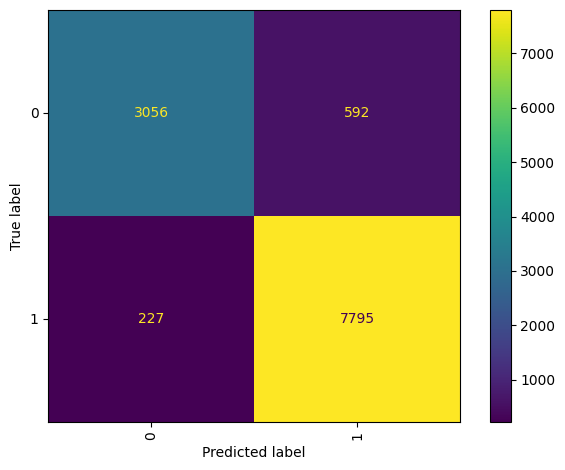

In [11]:
model_num_xgb = XGBClassifier(**study.best_params)
model_num_xgb.fit(X_train_n, y_train)

val_df['num_pred'] = model_num_xgb.predict(X_val_n)
accuracy = f1_score(y_val, val_df['num_pred'])
print(f"Validation f1: {accuracy}")

print(classification_report(y_val, val_df['num_pred']))

cm = confusion_matrix(y_val, val_df['num_pred'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Основные выводы:
- Модель сильная (93% accuracy);
- Легкий уклон к мажоритарному классу 1 (уязвимый): отличный recall (0.97), но для класса 0 (безопасный) recall ниже (0.85) - чаще путает миноритарный класс с мажоритарным;
- Если класс 0 важен — стоит повысить его recall.

В целом получена хорошая модель и выделены информативные признаки. Решение подходит для задач, где важнее не пропустить класс 1.

#### Сохранение результатов

In [12]:
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')

with open(f'inference/num_features/transformers/evm_extractor.pkl', 'wb') as f:
    pickle.dump(evm_extractor, f)

with open(f'inference/num_features/optuna_studies/num_xgb_study_{timestamp}.pkl', 'wb') as f:
    pickle.dump(study, f)

with open(f'inference/num_features/models/num_xgb_model_{timestamp}.pkl', 'wb') as f:
    pickle.dump(model_num_xgb, f)

### Текстовая последовательность инструкций

Для работы с текстовой последовательностью опкодов извечем их из байткода, заменив перенос строки на пробел. Развернутый код сохраним для переиспользования без предобработки.

In [13]:
y_train = train_df['is_vulnerable']
y_val = val_df['is_vulnerable']

X_train_o = train_df['bytecode'].parallel_apply(extract_raw_opcodes).str.replace(r'[ ].*\n|\n', ' ', regex=True)
X_val_o = val_df['bytecode'].parallel_apply(extract_raw_opcodes).str.replace(r'[ ].*\n|\n', ' ', regex=True)

X_train_o = pd.DataFrame(X_train_o)
X_val_o = pd.DataFrame(X_val_o)

X_train_o['is_vulnerable'] = y_train
X_val_o['is_vulnerable'] = y_val

X_train_o.to_parquet('datasets/train_o_features.parquet', engine='pyarrow')
X_val_o.to_parquet('datasets/val_o_features.parquet', engine='pyarrow')

X_train_o = X_train_o['bytecode']
X_val_o = X_val_o['bytecode']

In [14]:
train_df = pd.read_parquet('datasets/train_o_features.parquet', engine='pyarrow')
val_df = pd.read_parquet('datasets/val_o_features.parquet', engine='pyarrow')

X_train_o, X_val_o = train_df['bytecode'], val_df['bytecode']
y_train, y_val = train_df['is_vulnerable'], val_df['is_vulnerable']

In [15]:
print('Опкод слова на контракт:')
X_train_o.apply(lambda x: len(x.split(' '))).describe()

Опкод слова на контракт:


count    105027.000000
mean      10790.927828
std        7698.276841
min          31.000000
25%        4768.000000
50%        8765.000000
75%       15914.000000
max       39330.000000
Name: bytecode, dtype: float64

In [16]:
print('Уникальных опкод слов на контракт:')
X_train_o.apply(lambda x: len(set(x.split(' ')))).describe()

Уникальных опкод слов на контракт:


count    105027.000000
mean         16.177116
std           0.388959
min          10.000000
25%          16.000000
50%          16.000000
75%          16.000000
max          17.000000
Name: bytecode, dtype: float64

В среднем, полученные последовательности содержат около десяти тысяч слов. Минимум - 53 слова, максимум больше сорока тысяч. 

Если посчитать уникальные слова, то в среднем их 337 на контракт. Минимально - 23 слова, максимально - 4824.

Для обучения векторизаторов воспользуемся батчингом и особенностями каждого из них.

#### Выбор метода векторизации текста

Протестируем несколько классических методов векторизации текста:
- HashingVectorizer;
- CountVectorizer;
- TF-IDF.

##### HashingVectorizer

Векторизация, которая подсчитывает нграммы в тексте. Словаря не хранит, так как подставляет в качестве индекса murmur хеш слова, поэтому не сильно требовательна к количеству памяти. Не интерпретируема, однако работает быстро и не требует обучения. Может быть использована в последствии для получения признаков в потоке.

Векторизатор не обучаем, а получаем сразу последовательности признаков по батчам. Из них формируем полную csr матрицу обучающей выборки.

Рассматриваем последовательности от 1 до 3 слов, не более 2000 признаков - чтобы не пропустить уязвимости для более коротких контрактов. Для экономии памяти отключаем приведение к нижнему регистру - все опкоды и так только в верхнем.

In [17]:
batch_size = 1024

In [18]:
vectorizer = HashingVectorizer(
            token_pattern=r'\S+',
            ngram_range=(1, 3),
            n_features=2000,
            lowercase=False
        )

X_train_o_transformed = csr_matrix((0, vectorizer.n_features), dtype=np.float64)
for i in tqdm(range(0, len(X_train_o), batch_size)):
    X_train_transformed_batch = vectorizer.transform(X_train_o[i:i+batch_size])
    X_train_o_transformed = vstack([X_train_o_transformed, X_train_transformed_batch])

    del X_train_transformed_batch

100%|██████████| 103/103 [22:17<00:00, 12.98s/it]


На преобразованных данных сравним две базовые модели:
- LogisticRegression - обычный линейный классификатор со скейлером, работает быстро, однако может терять точность на большом числе признаков;
- DecisionTreeClassifier - дерево-классификатор, может уловить взаимодествие некоторых признаков.

In [19]:
pipeline_lr = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

score = cross_val_score(pipeline_lr, X_train_o_transformed, y_train, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print(score)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-l

[0.91546448 0.91662951 0.91603842 0.91498337 0.91525772]


In [22]:
model_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

score = cross_val_score(model_tree, X_train_o_transformed, y_train, cv=5, scoring='f1', n_jobs=30, verbose=1)

print(score)

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


KeyboardInterrupt: 

Логистическая регрессия дает лучшую метрику за значимо меньшее время, на следующих векторизаторах рассматриваем ее. Оценим возможность повышения качества прогноза используя модели-композиции. Для переиспользования трансформированную матрицу сохраняем в pkl формате.

In [23]:
with open('datasets/train_o_features_hash_2000_1_3.pkl', 'wb') as f:
    pickle.dump(X_train_o_transformed, f)

##### CountVectorizer

Для CountVectorizer придется предварительно сформировать словарь нграмм, который по сути отражает метод fit. Далее обновленным векторизатором с заполненным словарем трансформируем текст.

In [24]:
batch_size = 1024
max_features = 2000
global_token_counts = defaultdict(int)

def process_batch(batch_data):
    temp_vectorizer = CountVectorizer(
        token_pattern=r'\S+',
        ngram_range=(1, 3),
        lowercase=False
    )
    temp_vectorizer.fit(batch_data)
    return temp_vectorizer.vocabulary_

batches = [X_train_o[i:i + batch_size] for i in range(0, len(X_train_o), batch_size)]

results = Parallel(n_jobs=-1, verbose=0)(
    delayed(process_batch)(batch) for batch in tqdm(batches, desc="Collecting vocabulary")
)

for vocabulary in results:
    for token, count in vocabulary.items():
        global_token_counts[token] += 1

top_tokens = sorted(global_token_counts.items(), key=lambda x: x[1], reverse=True)[:max_features]
top_tokens_sorted = sorted(top_tokens, key=lambda x: x[0])
final_vocabulary = {token: idx for idx, (token, _) in enumerate(top_tokens_sorted)}

In [25]:
vectorizer_с = CountVectorizer(
    token_pattern=r'\S+',
    ngram_range=(1, 3),
    lowercase=False,
    max_features=max_features,
    vocabulary=final_vocabulary
)

X_train_o_transformed = csr_matrix((0, max_features), dtype=np.float64)
for i in tqdm(range(0, len(X_train_o), batch_size), desc="Final transform"):
    X_train_transformed_batch = vectorizer_с.transform(X_train_o[i:i+batch_size])
    X_train_o_transformed = vstack([X_train_o_transformed, X_train_transformed_batch])

    del X_train_transformed_batch

Final transform: 100%|██████████| 103/103 [19:15<00:00, 11.22s/it]


In [26]:
pipeline_lr = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

score = cross_val_score(pipeline_lr, X_train_o_transformed, y_train, cv=5, scoring='f1', n_jobs=30, verbose=1)

print(score)

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-l

[0.91338638 0.91537012 0.91535743 0.91305409 0.91571055]


In [28]:
model_rfc_count = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

score = cross_val_score(model_rfc_count, X_train_o_transformed, y_train, cv=5, scoring='f1', n_jobs=30, verbose=1)

print(score)

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


[0.95157995 0.9516536  0.95167235 0.94826292 0.95173073]


[Parallel(n_jobs=30)]: Done   5 out of   5 | elapsed:  3.8min finished


In [29]:
X_train_o_transformed = pd.DataFrame.sparse.from_spmatrix(
    X_train_o_transformed,
    columns=vectorizer_с.get_feature_names_out(), 
    index=X_train_o.index
)

with open('datasets/train_o_features_count_2000_1_3.pkl', 'wb') as f:
    pickle.dump(X_train_o_transformed, f)

with open('inference/opcodes/transformers/count_vectorizer_2000_1_3.pkl', 'wb') as f:
    pickle.dump(vectorizer_с, f)

##### TF-IDFVectorizer

In [30]:
batch_size = 1024
max_features = 2000

global_df = defaultdict(int)

def collect_df(batch_data):
    temp_vec = TfidfVectorizer(
        token_pattern=r'\S+',
        ngram_range=(1, 3),
        lowercase=False,
        use_idf=False,
        norm=None,
        smooth_idf=False,
        sublinear_tf=False
    )
    temp_vec.fit(batch_data)
    return set(temp_vec.get_feature_names_out())

batch_token_sets = Parallel(n_jobs=-1)(
    delayed(collect_df)(batch) for batch in tqdm([X_train_o[i:i + batch_size] for i in range(0, len(X_train_o), batch_size)], desc="Collecting DF (pass 1)")
)

for token_set in batch_token_sets:
    for token in token_set:
        global_df[token] += 1


top_tokens = sorted(global_df.items(), key=lambda x: x[1], reverse=True)[:max_features]
top_tokens_sorted = sorted(top_tokens, key=lambda x: x[0])
final_vocabulary = {token: idx for idx, (token, _) in enumerate(top_tokens_sorted)}
num_features = len(final_vocabulary)

In [31]:
vectorizer_t = TfidfVectorizer(
    token_pattern=r'\S+',
    ngram_range=(1, 3),
    lowercase=False,
    vocabulary=final_vocabulary,
    norm='l2',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=False
)
vectorizer_t.fit(tqdm(X_train_o, desc="Fitting TF-IDF (computing IDF)"))

Fitting TF-IDF (computing IDF): 100%|██████████| 105027/105027 [21:37<00:00, 80.96it/s] 


TfidfVectorizer(lowercase=False, ngram_range=(1, 3), token_pattern='\\S+',
                vocabulary={'ADDRESS': 0, 'ADDRESS ADDRESS': 1,
                            'ADDRESS ADDRESS BALANCE': 2,
                            'ADDRESS ADDRESS CALLDATACOPY': 3,
                            'ADDRESS ADDRESS CALLDATASIZE': 4,
                            'ADDRESS ADDRESS CALLER': 5,
                            'ADDRESS ADDRESS CALLVALUE': 6,
                            'ADDRESS ADDRESS PUSH3': 7,
                            'ADDRESS ADDRESS PUSH4': 8,
                            'ADDRESS ADDRESS PUSH5': 9,
                            'ADDRESS BALANCE ADDRESS'...
                            'ADDRESS CALLDATACOPY CALLER': 18,
                            'ADDRESS CALLDATACOPY PUSH3': 19,
                            'ADDRESS CALLDATACOPY PUSH5': 20,
                            'ADDRESS CALLDATACOPY PUSH6': 21,
                            'ADDRESS CALLDATALOAD BALANCE': 22,
                            'ADDRESS CALLDATALOAD CALLDATACOPY': 23,
                            'ADDRESS CALLDATALOAD CODESIZE': 24,
                            'ADDRESS CALLDATALOAD PUSH2': 25,
                            'ADDRESS CALLDATALOAD PUSH6': 26,
                            'ADDRESS CALLDATALOAD PUSH7': 27,
                            'ADDRESS CALLDATASIZE': 28,
                            'ADDRESS CALLDATASIZE ADDRESS': 29, ...})

In [ ]:
X_train_o_transformed = csr_matrix((0, num_features), dtype=np.float64)
for i in tqdm(range(0, len(X_train_o), batch_size), desc="TF-IDF transform (pass 2)"):
    batch = X_train_o[i:i + batch_size]
    batch_X = vectorizer.transform(batch)
    
    X_train_o_transformed = vstack([X_train_o_transformed, batch_X])
    
    del batch_X

TF-IDF transform (pass 2): 100%|██████████| 103/103 [22:13<00:00, 12.94s/it]


In [ ]:
model_rfc_tfidf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

score = cross_val_score(model_rfc_tfidf, X_train_o_transformed, y_train, cv=5, scoring='f1', n_jobs=-1)

print(score)

[0.94741841 0.94824833 0.94858542 0.94635076 0.94824719]


In [ ]:
with open('datasets/train_o_features_tfidf_2000_1_3.pkl', 'wb') as f:
    pickle.dump(X_train_o_transformed, f)

with open('inference/opcodes/transformers/tfidf_vectorizer_2000_1_3.pkl', 'wb') as f:
    pickle.dump(vectorizer_t, f)

#### Проверка на валидации

In [35]:
with open('inference/opcodes/transformers/count_vectorizer_2000_1_3.pkl', 'rb') as f:
    vectorizer_с = pickle.load(f)

X_val_o_transformed = vectorizer_с.transform(X_val_o)

In [36]:
model_opcode_rfc = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

model_opcode_rfc.fit(X_train_o_transformed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Validation f1: 0.6678003158022593
              precision    recall  f1-score   support

           0       0.22      0.19      0.20      3648
           1       0.65      0.69      0.67      8022

    accuracy                           0.53     11670
   macro avg       0.43      0.44      0.44     11670
weighted avg       0.52      0.53      0.52     11670



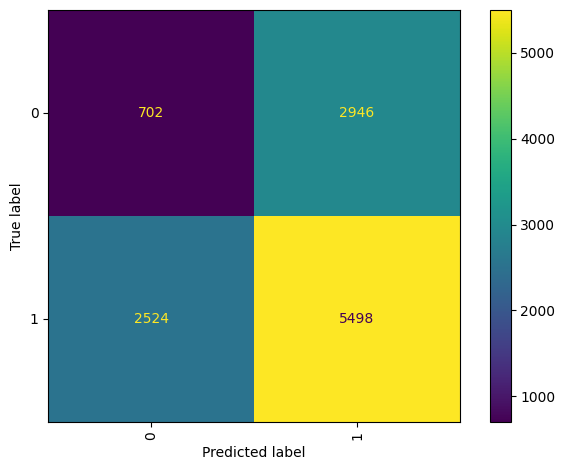

In [37]:
val_df['opcode_pred'] = model_opcode_rfc.predict(X_val_o_transformed)
accuracy = f1_score(y_val, val_df['opcode_pred'])
print(f"Validation f1: {accuracy}")

print(classification_report(y_val, val_df['opcode_pred']))

cm = confusion_matrix(y_val, val_df['opcode_pred'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [38]:
with open('inference/opcodes/models/rfc_proba_predictor_default.pkl', 'wb') as f:
    pickle.dump(model_opcode_rfc, f)

del X_train_o_transformed

### Объединение признаков
#### Создание финального тренировочного датасета

Загрузим преобразованные сохраненные данные.  Для создания итогового тренировочного датасета, на котором будет обучена финальная модель объединим числовые признаки с вероятностью (proba) уязвимостей в контракте, полученной из текстовой последовательности инструкций при помощи векторизации и модели решающий лес с дефолтными параметрами. (Дает лучшую f1 по сравнению с остальными, попытка подбора параметров практически не повышает качество для бустингов, для леса вызывает BSOD).

Вероятности будем получать out-of-fold методом для избежания переобучения модели на данных, которые она уже видела. Для валидационной выборки и дальнейшего инференса обучим еще одну модель на всех данных и экспортируем в pickle формате.

In [39]:
with open('datasets/train_o_features_count_2000_1_3.pkl', 'rb') as f:
    X_train_o_transformed = pickle.load(f)

X_train_n = pd.read_parquet('datasets/train_n_features.parquet', engine='pyarrow')
y_train = X_train_n['is_vulnerable']

В качестве итератора используем стратифицированный k-fold. Лишние модели удаляем для экономии памяти.

In [40]:
X_train_n['oof_vuln_proba'] = np.nan
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for train_index, test_index in tqdm(skf.split(X_train_o_transformed, y_train)):
    model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train_o_transformed.iloc[train_index], y_train.iloc[train_index])
    X_train_n.iloc[test_index, X_train_n.columns.get_loc('oof_vuln_proba')] = model.predict_proba(X_train_o_transformed.iloc[test_index])[:, 1]
    del model

X_train_n.to_parquet('datasets/train_final_features.parquet', engine='pyarrow')
X_train_n = X_train_n.drop(columns=['is_vulnerable'])

5it [05:44, 68.90s/it]


In [41]:
models = [
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('logreg', LogisticRegression(random_state=RANDOM_STATE))
    ]),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for train_index, test_index in tqdm(skf.split(X_train_n, y_train)):
    for model in models:
        if model.__class__.__name__ not in results:
            results[model.__class__.__name__] = {
                'acc': [],
                'f1': []
            }

        model.fit(X_train_n.iloc[train_index], y_train.iloc[train_index])
        preds = model.predict(X_train_n.iloc[test_index])

        results[model.__class__.__name__]['acc'].append(accuracy_score(y_train.iloc[test_index], preds))
        results[model.__class__.__name__]['f1'].append(f1_score(y_train.iloc[test_index], preds))

        del model

for model, metrics in results.items():
    print(model)
    print('acc:', np.mean(metrics['acc']))
    print('f1:', np.mean(metrics['f1']))
    print()

5it [01:00, 12.10s/it]

Pipeline
acc: 0.9320365414916534
f1: 0.95108560964505

DecisionTreeClassifier
acc: 0.9046911727853774
f1: 0.9305957167694416

RandomForestClassifier
acc: 0.9372828062432509
f1: 0.9546908091754454

XGBClassifier
acc: 0.934959587044456
f1: 0.9529069917477784



На итоговом тренировочном датасете наибольшие значения метрик у RFC и XGBC. Попробуем поднять качество для XGBC при помощи optuna с EarlyStopping на валидационной выборке.

#### Валидационная выборка

Код ниже содержит, в том числе, пример, как использовать обученные инференсы для преобразования входного байткода.

In [42]:
# Загружаем валидационный датасет, нас интересуют пока только поля bytecode и лейбл.
val_df = pd.read_parquet('datasets/val.parquet', engine='pyarrow')
# val_df = val_df[['bytecode', 'is_vulnerable']]
val_df.sample(1).values

array([['e9ce4238f1ee0e4882cb02da2938d26c631fe09c',
        'pragma solidity ^0.4.4;\n\ncontract Token {\n    function totalSupply() constant returns (uint256 supply) {}\n    function balanceOf(address _owner) constant returns (uint256 balance) {}\n    function transfer(address _to, uint256 _value) returns (bool success) {}\n    function transferFrom(address _from, address _to, uint256 _value) returns (bool success) {}\n    function approve(address _spender, uint256 _value) returns (bool success) {}\n    function allowance(address _owner, address _spender) constant returns (uint256 remaining) {}\n    event Transfer(address indexed _from, address indexed _to, uint256 _value);\n    event Approval(address indexed _owner, address indexed _spender, uint256 _value);\n}\ncontract StandardToken is Token {\n    function transfer(address _to, uint256 _value) returns (bool success) {\n        if (balances[msg.sender] >= _value && _value > 0) {\n            balances[msg.sender] -= _value;\n       

In [43]:
# Загружаем экстрактор, он обучения не требует и может работать сразу как есть.
extractor = EVMBytecodeFeatureExtractor()

# Получаем числовые признаки из байткода
X_val_n = extractor.transform(val_df[['bytecode']])
y_val = val_df['is_vulnerable']

In [44]:
# Подгружаем предобученный векторизатор
with open('inference/opcodes/transformers/count_vectorizer_2000_1_3.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Подгружаем предобученный предиктор (он даст дополнительный признак к числовым - вероятность наличия уязвимости из последовательностей опкодов)
with open('inference/opcodes/models/rfc_proba_predictor_default.pkl', 'rb') as f:
    proba_predictor = pickle.load(f)

# Разворачиваем байт последовательность в последовательсность опкодов 
X_val_o = val_df['bytecode'].parallel_apply(extract_raw_opcodes).str.replace(r'[ ].*\n|\n', ' ', regex=True)
# Векторизуем полученную последовательность
X_val_o = vectorizer.transform(tqdm(X_val_o))

# Получаем признак-вероятность из полученной из векторизатора матрицы
X_val_n['oof_vuln_proba'] = proba_predictor.predict_proba(X_val_o)[:, 1]

100%|██████████| 11670/11670 [02:12<00:00, 88.32it/s] 


#### Подбор параметров для финальной модели
Попробуем поднять точность для модели бустинга.

In [45]:
from xgboost import DMatrix, train

D_train = DMatrix(X_train_n, y_train)
D_valid = DMatrix(X_val_n, y_val)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 20, step=1),
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'n_jobs': -1,
    }

    bst = train(
        params,
        D_train,
        num_boost_round=10000,
        evals=[(D_valid, 'validation')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    preds = bst.predict(D_valid, iteration_range=(0, bst.best_iteration + 1))
    score = f1_score(y_val, preds > 0.5)

    return score

# Создаём study и запускаем
study = optuna.create_study(direction='maximize')  # потому что AUC больше = лучше
study.optimize(objective, n_trials=500)

print('Best params:', study.best_params)
print('Best F1:', study.best_value)

[I 2026-05-30 16:40:09,517] A new study created in memory with name: no-name-08cafd9a-6da5-44d1-a02d-aba525c51b84


[16:40:09] WARNING: ../src/learner.cc:767: 
Parameters: { "n_estimators" } are not used.



[I 2026-05-30 16:40:09,947] Trial 0 finished with value: 0.5444952962115434 and parameters: {'max_depth': 8, 'learning_rate': 0.2783884768230502, 'n_estimators': 700, 'min_child_weight': 7, 'gamma': 0.9478596192862743, 'subsample': 0.7912397065104271, 'colsample_bytree': 0.6904441046695782, 'reg_alpha': 1.627742182507048, 'reg_lambda': 2.2505541201449724, 'scale_pos_weight': 7.0}. Best is trial 0 with value: 0.5444952962115434.


[16:40:09] WARNING: ../src/learner.cc:767: 
Parameters: { "n_estimators" } are not used.



[I 2026-05-30 16:40:10,380] Trial 1 finished with value: 0.8249091852620652 and parameters: {'max_depth': 8, 'learning_rate': 0.014147898023917676, 'n_estimators': 400, 'min_child_weight': 10, 'gamma': 4.321544398081761, 'subsample': 0.9359205030718176, 'colsample_bytree': 0.6048469466736165, 'reg_alpha': 0.5904627533094073, 'reg_lambda': 1.4520049447889432, 'scale_pos_weight': 10.0}. Best is trial 1 with value: 0.8249091852620652.


...

[16:46:37] WARNING: ../src/learner.cc:767: 
Parameters: { "n_estimators" } are not used.



[I 2026-05-30 16:46:38,683] Trial 498 finished with value: 0.9310387367382186 and parameters: {'max_depth': 12, 'learning_rate': 0.01182328469307939, 'n_estimators': 300, 'min_child_weight': 4, 'gamma': 0.7941013011697776, 'subsample': 0.69683060543023, 'colsample_bytree': 0.40963793566044315, 'reg_alpha': 0.3331033913910727, 'reg_lambda': 4.075441540598984, 'scale_pos_weight': 1.0}. Best is trial 483 with value: 0.931444410224823.


[16:46:38] WARNING: ../src/learner.cc:767: 
Parameters: { "n_estimators" } are not used.



[I 2026-05-30 16:46:40,041] Trial 499 finished with value: 0.9286419753086419 and parameters: {'max_depth': 12, 'learning_rate': 0.013232446279431195, 'n_estimators': 300, 'min_child_weight': 4, 'gamma': 0.7108588465176202, 'subsample': 0.699009517526699, 'colsample_bytree': 0.40940576145902297, 'reg_alpha': 0.33354735379226164, 'reg_lambda': 4.056779287267565, 'scale_pos_weight': 1.0}. Best is trial 483 with value: 0.931444410224823.


Best params: {'max_depth': 12, 'learning_rate': 0.012780817968863099, 'n_estimators': 300, 'min_child_weight': 4, 'gamma': 1.1516154458664125, 'subsample': 0.7166068945502976, 'colsample_bytree': 0.4117197404752657, 'reg_alpha': 0.20493226120693922, 'reg_lambda': 3.8749778788261637, 'scale_pos_weight': 1.0}
Best F1: 0.931444410224823


Финальную модель создаем из лучших параметров найденных поиском и сохраняем. Важность признаков дополнительно импортируем в csv.

In [46]:
final_classifier = XGBClassifier(**study.best_params)
final_classifier.fit(X_train_n, y_train)

with open('inference/final_classifier.pkl', 'wb') as f:
    pickle.dump(final_classifier, f)

feature_importance = pd.DataFrame(final_classifier.feature_importances_, columns=['importance'], index=X_train_n.columns)
feature_importance.sort_values(by='importance', ascending=False)

feature_importance.to_csv('inference/feature_importance_from_xgb.csv', index=True)

Итоговые метрики

In [47]:
val_preds = final_classifier.predict(X_val_n)
print('Final acc on val:', accuracy_score(y_val, val_preds))
print('Final f1 on val:', f1_score(y_val, val_preds))

Final acc on val: 0.8236503856041131
Final f1 on val: 0.8670714377987341


Validation f1: 0.8670714377987341
              precision    recall  f1-score   support

           0       0.69      0.79      0.74      3648
           1       0.90      0.84      0.87      8022

    accuracy                           0.82     11670
   macro avg       0.79      0.82      0.80     11670
weighted avg       0.83      0.82      0.83     11670



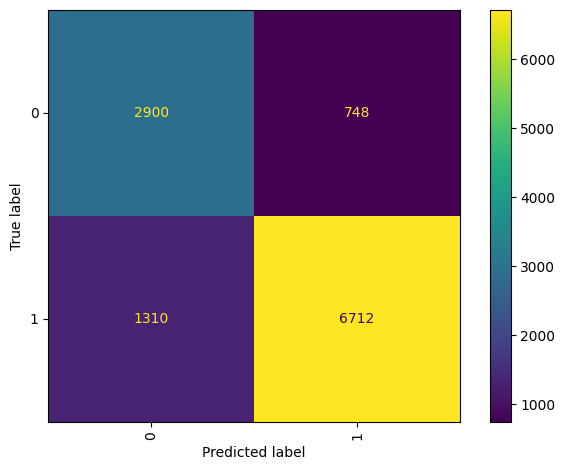

In [48]:
accuracy = f1_score(y_val, val_preds)
print(f"Validation f1: {accuracy}")

print(classification_report(y_val, val_preds))

cm = confusion_matrix(y_val, val_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Интерпретация результатов

Для интерпретации нам нужно понять, что повлияло на прогноз. Рассмотрим shap значения для пограничных случаев, когда 'oof_vuln_proba' от 0.4 до 0.6.

In [49]:
%pip install shap -q


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


#### Применение shap для одного кода

Ниже пример кода для простой визуализации встроенными методами shap для одного преобразованного в признаки байткода.

Prediction: [0] True label: 0


,total_instructions,unique_instructions,block_dependent_count,block_dependency_index,has_TIMESTAMP,has_NUMBER,has_DIFFICULTY,has_GASLIMIT,has_COINBASE,has_BLOCKHASH,environmental_instructions_count,environmental_ratio,unique_environmental_ops,environmental_complexity,balance_operations,address_operations,caller_operations,origin_operations,callvalue_operations,external_dependency_index,calldata_size_ops,calldata_load_ops,calldata_copy_ops,total_calldata_ops,calldata_density,external_call_count,has_external_calls,call_value_ops,call_gas_limit_ops,potential_reentrancy_pattern,pushes,pops,stack_imbalance,stack_operations_ratio,stack_underflow_risk,total_gas_cost,avg_gas_per_instruction,max_gas_instruction,high_gas_instructions,gas_dos_risk_index,arithmetic_ops_count,arithmetic_density,unsafe_arithmetic_pattern,control_flow_ops,jumpi_count,conditional_branching_ratio,control_flow_complexity,caller_based_checks,origin_usage,access_control_ratio,uses_origin_instead_caller,balance_before_external_call,randomness_ops_count,has_bad_randomness_pattern,dangerous_ops_count,dangerous_ops_density,opcode_entropy,reentrancy_risk_score,frontrunning_risk_score,dos_risk_score,arithmetic_risk_score,overall_security_risk_score,has_reentrancy_indicators,has_unchecked_external_calls,has_arithmetic_vulnerabilities,has_access_control_issues,has_dos_vulnerabilities,oof_vuln_proba
114764,2858,60,0,0.0,0,0,0,0,0,0,64,0.022393,9,0.20154,0,1,13,0,1,0.0,13,26,1,40,0.013996,2,1,1,2,0,3936,3923,13,0.996697,0,45568,15.944017,1500,6,0.002099,270,0.094472,0,173,67,0.558333,1.570679,13,0,6.5,0,0,0,0,272,0.095171,3.259658,0.00105,0.0,0.00265,0.094472,0.032224,0,0,0,0,0,0.6


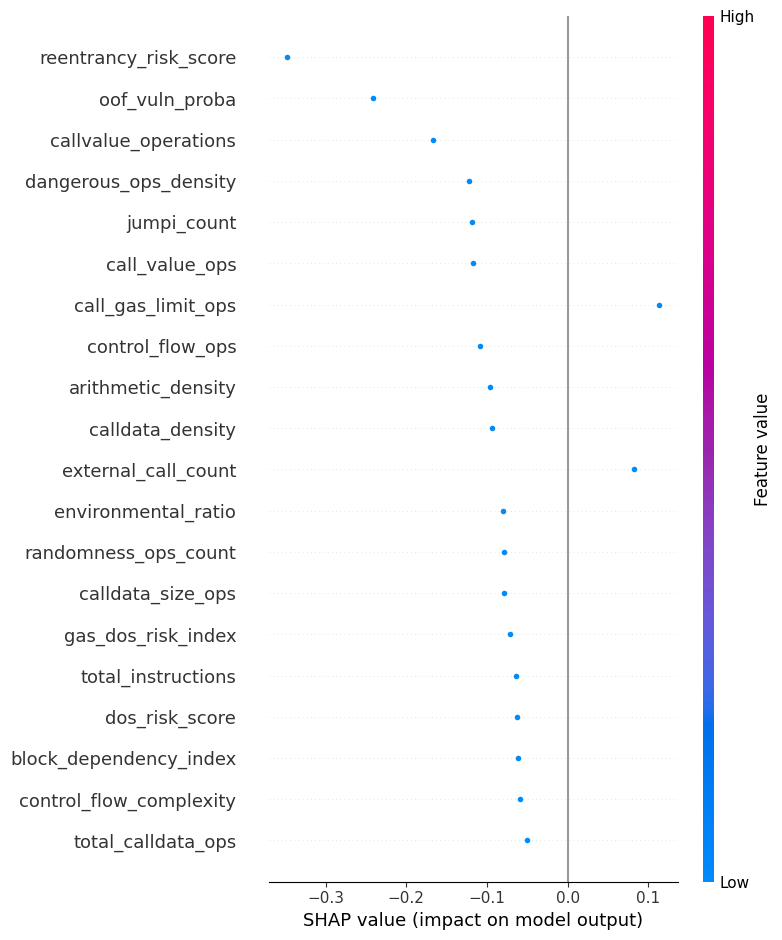

[[-6.34608641e-02 -3.20756435e-02 -1.80838127e-02 -6.13065474e-02
  -2.07206961e-02  1.10793533e-03  3.14194651e-04  4.31443984e-03
  -2.50557601e-03 -1.57127943e-07 -2.27467660e-02 -8.02126676e-02
  -4.76588681e-03 -2.89881937e-02  1.61240029e-03 -1.30445026e-02
  -1.48343602e-02  5.62142907e-03 -1.66646540e-01 -3.13290097e-02
  -7.89079890e-02 -4.61076212e-04 -6.47566374e-03 -5.05995303e-02
  -9.35768858e-02  8.20332542e-02  2.19386313e-02 -1.16751455e-01
   1.13565750e-01  1.49356201e-04 -4.25456986e-02 -1.32695055e-02
  -3.24406177e-02 -1.91560648e-02  1.17842419e-05 -2.58416384e-02
  -6.17343583e-04 -3.25842272e-03 -4.05869819e-02 -7.18887374e-02
  -3.88734788e-02 -9.65820402e-02 -1.58754137e-05 -1.08390063e-01
  -1.18318349e-01 -3.77291888e-02 -5.89665286e-02 -4.45372285e-03
   3.42881610e-03 -3.11259069e-02  1.13168026e-04  0.00000000e+00
  -7.94174522e-02 -2.86264867e-02 -1.83029734e-02 -1.21683963e-01
  -1.64556261e-02 -3.47338140e-01 -2.67710090e-02 -6.27333596e-02
  -3.03462

In [50]:
import shap

# Берем сэмпл из валидации, если проверяем просто байткод на вход, тогда датафрейм полученных признаков после трансформаций
data_sample = X_val_n[X_val_n['oof_vuln_proba'].isin([0.4, 0.6])].sample(1, random_state=123)
# Предсказание моделью и настоящий лейбл для наглядности
prediction = final_classifier.predict(data_sample)
true_label = y_val[data_sample.index[0]]

# Финальную модель отправляем в эксплейнер, должно работать при загрузке из pickle
explainer = shap.TreeExplainer(final_classifier)
# Считаем shap значения на семпле (какой признак куда уводит прогноз)
shap_value = explainer.shap_values(data_sample)

# Предсказание / Истина
print('Prediction:', prediction, 'True label:', true_label)
# Значения признаков семпла
display(data_sample.head())
# График значимости встроенными методами, может быть неудобен, предлагаю plotly на самих значениях
shap.summary_plot(shap_value, data_sample)
# Сами SHAP значения для признаков по порядку, как идут признаки, названия можно взять из семпла data_sample.columns
print(shap_value)

#### Значимость последовательности опкодов

Будет позднее

<Axes: >

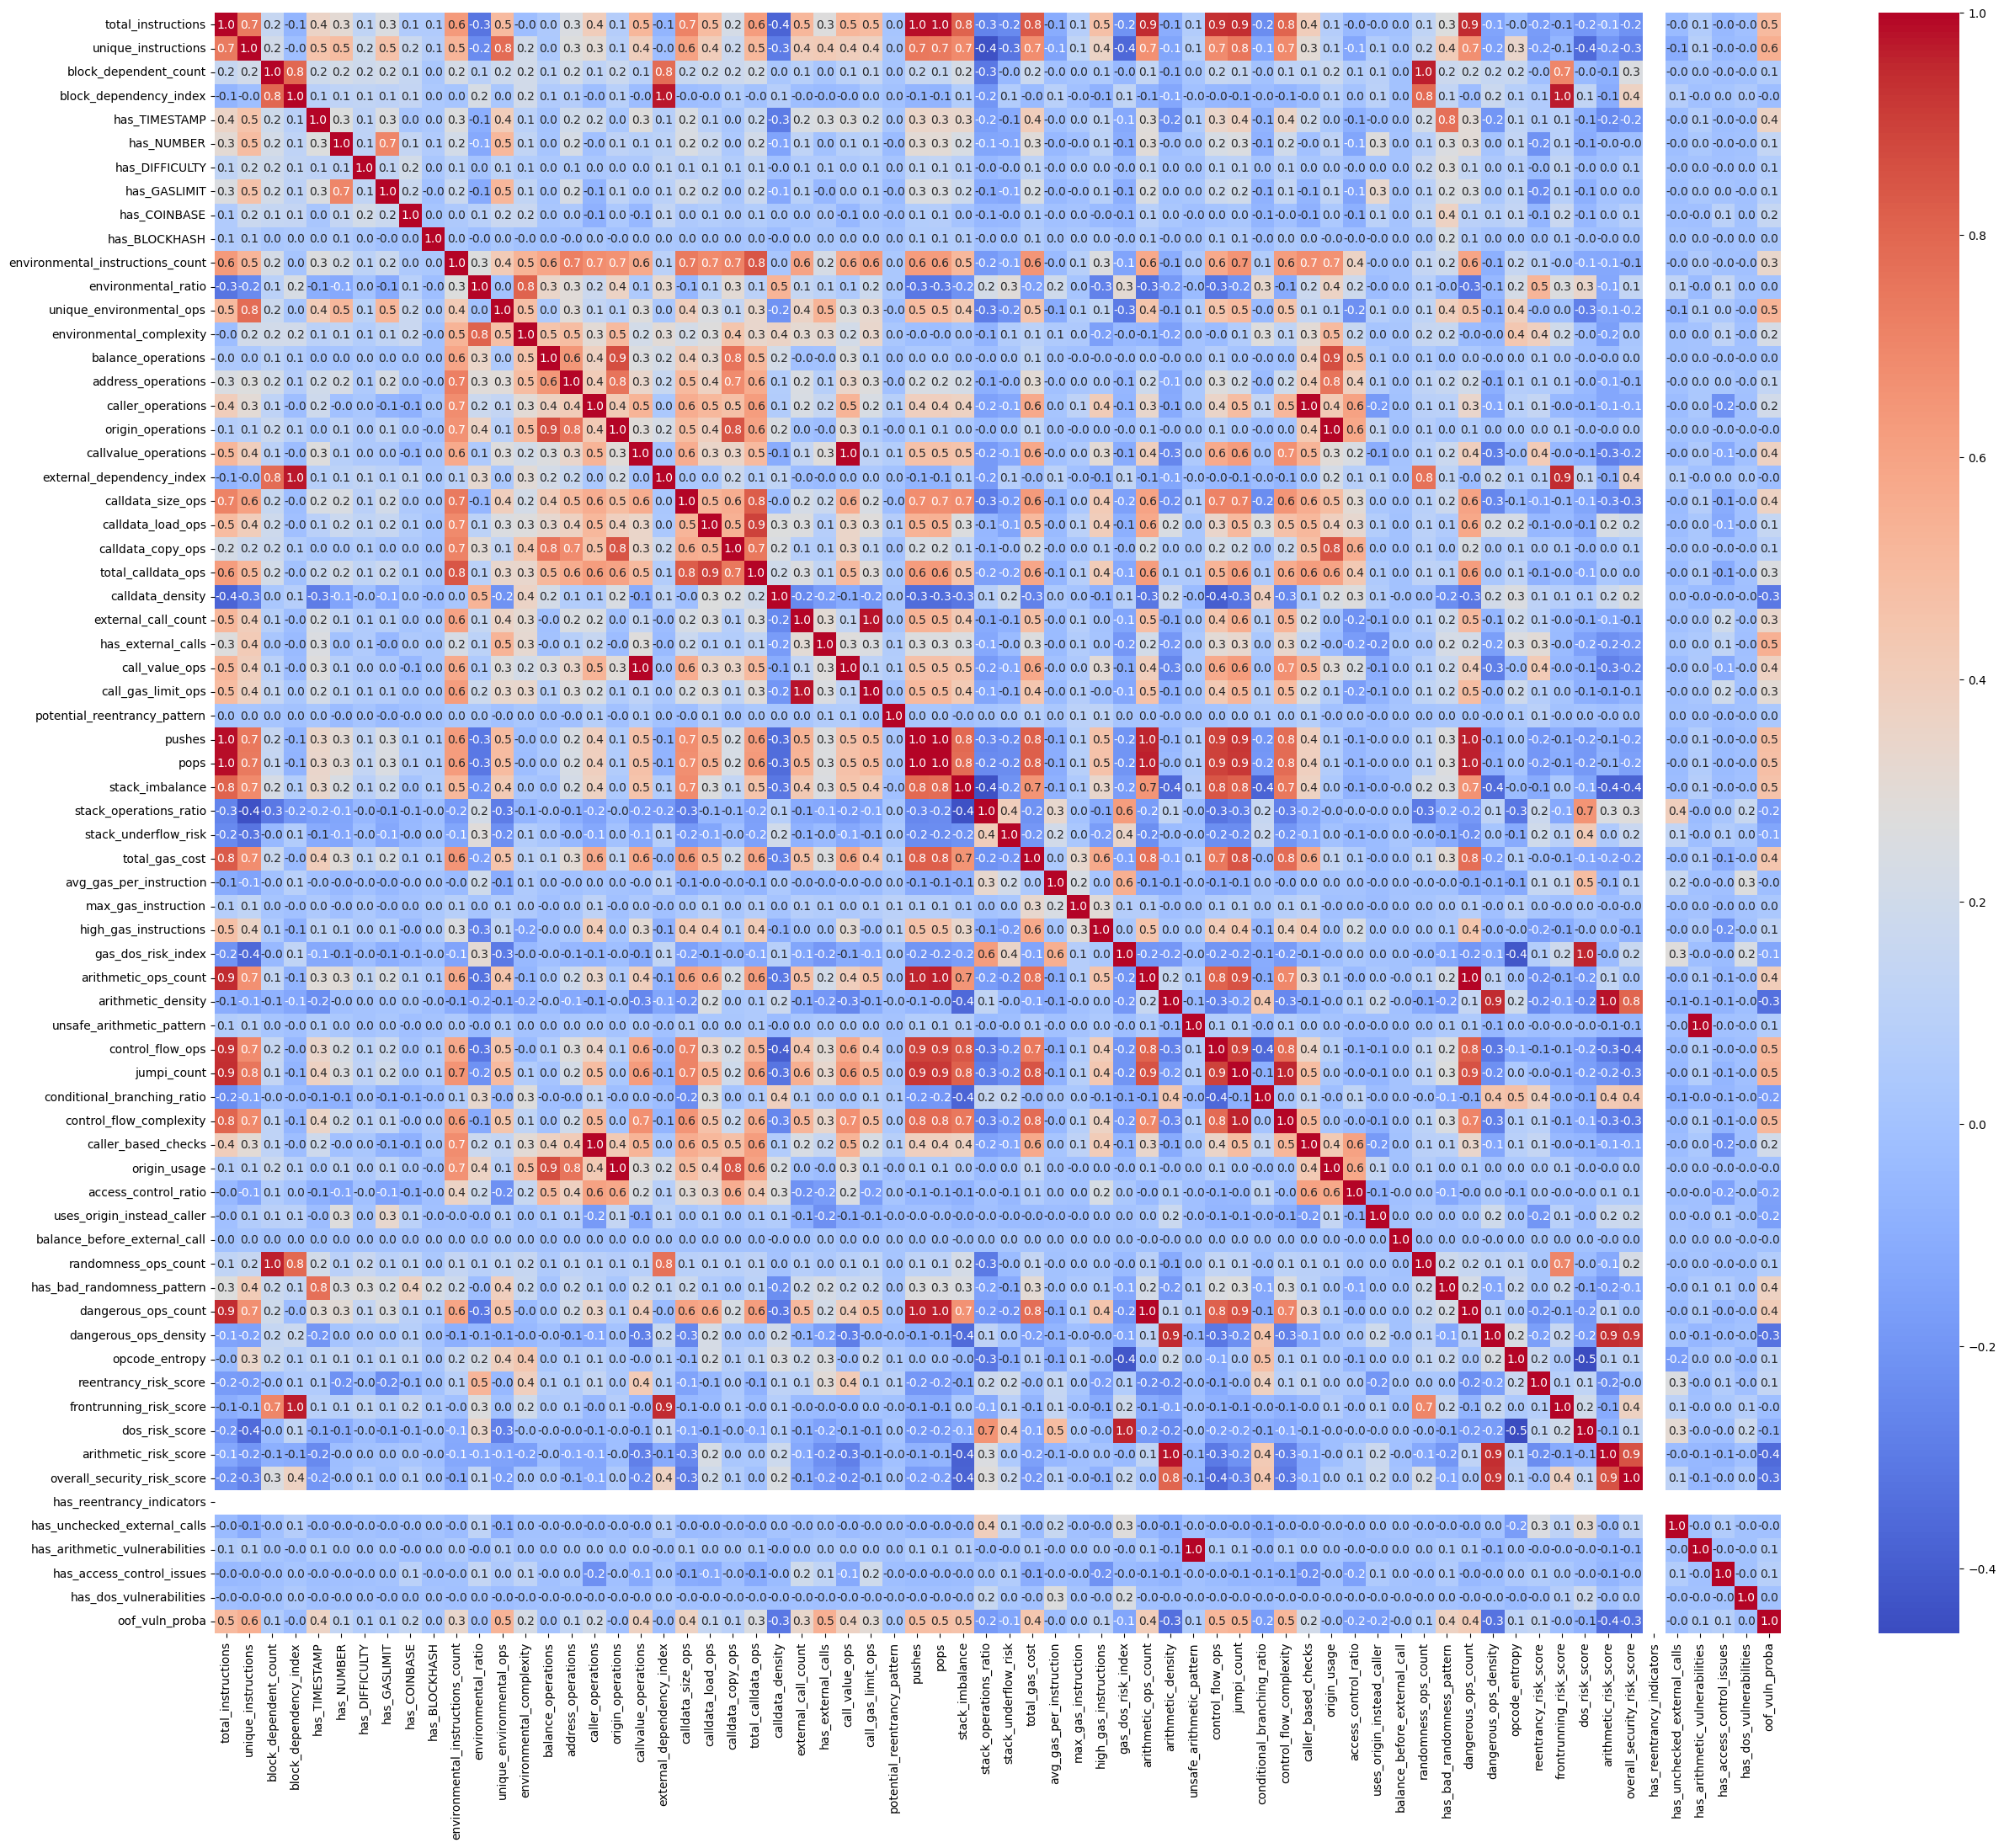

In [51]:
import seaborn as sns

corr_matrix = X_train_n.corr()

plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.1f')

In [52]:
with open('datasets/train_o_features_count_2000_1_3.pkl', 'rb') as f:
    X_train_o_transformed = pickle.load(f)

In [53]:
models = [
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ]),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for train_index, test_index in tqdm(skf.split(X_train_o_transformed, y_train)):
    for model in models:
        if model.__class__.__name__ not in results:
            results[model.__class__.__name__] = {
                'acc': [],
                'f1': []
            }

        model.fit(X_train_o_transformed.iloc[train_index], y_train.iloc[train_index])
        preds = model.predict(X_train_o_transformed.iloc[test_index])

        results[model.__class__.__name__]['acc'].append(accuracy_score(y_train.iloc[test_index], preds))
        results[model.__class__.__name__]['f1'].append(f1_score(y_train.iloc[test_index], preds))

        del model

for model, metrics in results.items():
    print(model)
    print('acc:', np.mean(metrics['acc']))
    print('f1:', np.mean(metrics['f1']))
    print()

0it [10:24, ?it/s]


KeyboardInterrupt: 

In [54]:
with open('datasets/train_o_features_hash_2000_1_3.pkl', 'rb') as f:
    X_train_o_transformed = pickle.load(f)

X_train_o_transformed = pd.DataFrame(X_train_o_transformed.toarray())

In [ ]:
models = [
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ]),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=30),
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=30),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for train_index, test_index in tqdm(skf.split(X_train_o_transformed, y_train)):
    for model in models:
        if model.__class__.__name__ not in results:
            results[model.__class__.__name__] = {
                'acc': [],
                'f1': []
            }

        model.fit(X_train_o_transformed.iloc[train_index], y_train.iloc[train_index])
        preds = model.predict(X_train_o_transformed.iloc[test_index])

        results[model.__class__.__name__]['acc'].append(accuracy_score(y_train.iloc[test_index], preds))
        results[model.__class__.__name__]['f1'].append(f1_score(y_train.iloc[test_index], preds))

        del model

for model, metrics in results.items():
    print(model)
    print('acc:', np.mean(metrics['acc']))
    print('f1:', np.mean(metrics['f1']))
    print()

2it [32:53, 986.58s/it]


KeyboardInterrupt: 

In [56]:
with open('datasets/train_o_features_tfidf_2000_1_3.pkl', 'rb') as f:
    X_train_o_transformed = pickle.load(f)

X_train_o_transformed = pd.DataFrame(X_train_o_transformed.toarray())

In [ ]:
models = [
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('model', LogisticRegression(random_state=RANDOM_STATE))
    ]),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for train_index, test_index in tqdm(skf.split(X_train_o_transformed, y_train)):
    for model in models:
        if model.__class__.__name__ not in results:
            results[model.__class__.__name__] = {
                'acc': [],
                'f1': []
            }

        model.fit(X_train_o_transformed.iloc[train_index], y_train.iloc[train_index])
        preds = model.predict(X_train_o_transformed.iloc[test_index])

        results[model.__class__.__name__]['acc'].append(accuracy_score(y_train.iloc[test_index], preds))
        results[model.__class__.__name__]['f1'].append(f1_score(y_train.iloc[test_index], preds))

        del model

for model, metrics in results.items():
    print(model)
    print('acc:', np.mean(metrics['acc']))
    print('f1:', np.mean(metrics['f1']))
    print()

In [57]:
X_train_n = pd.read_parquet('datasets/train_final_features.parquet', engine='pyarrow')

In [58]:
X_train_n

,total_instructions,unique_instructions,block_dependent_count,block_dependency_index,has_TIMESTAMP,has_NUMBER,has_DIFFICULTY,has_GASLIMIT,has_COINBASE,has_BLOCKHASH,environmental_instructions_count,environmental_ratio,unique_environmental_ops,environmental_complexity,balance_operations,address_operations,caller_operations,origin_operations,callvalue_operations,external_dependency_index,calldata_size_ops,calldata_load_ops,calldata_copy_ops,total_calldata_ops,calldata_density,external_call_count,has_external_calls,call_value_ops,call_gas_limit_ops,potential_reentrancy_pattern,pushes,pops,stack_imbalance,stack_operations_ratio,stack_underflow_risk,total_gas_cost,avg_gas_per_instruction,max_gas_instruction,high_gas_instructions,gas_dos_risk_index,arithmetic_ops_count,arithmetic_density,unsafe_arithmetic_pattern,control_flow_ops,jumpi_count,conditional_branching_ratio,control_flow_complexity,caller_based_checks,origin_usage,access_control_ratio,uses_origin_instead_caller,balance_before_external_call,randomness_ops_count,has_bad_randomness_pattern,dangerous_ops_count,dangerous_ops_density,opcode_entropy,reentrancy_risk_score,frontrunning_risk_score,dos_risk_score,arithmetic_risk_score,overall_security_risk_score,has_reentrancy_indicators,has_unchecked_external_calls,has_arithmetic_vulnerabilities,has_access_control_issues,has_dos_vulnerabilities,is_vulnerable,oof_vuln_proba
22240,29,21,0,0.000000,0,0,0,0,0,0,4,0.137931,4,0.551724,1,1,1,0,0,0.034483,0,0,0,0,0.000000,0,0,0,1,0,19,22,-3,1.157895,1,1911,65.896552,1125,1,0.034483,1,0.034483,0,8,0,0.000000,0.000000,1,0,1.000000,0,0,0,0,1,0.034483,2.880550,0.000000,0.001189,0.070155,0.068966,0.034879,0,0,0,0,0,1,0.65
73905,12960,85,6,0.000463,1,0,0,0,0,0,114,0.008796,8,0.070370,0,0,16,0,26,0.000463,28,20,5,53,0.004090,5,1,26,3,0,19456,18932,524,0.973067,0,124841,9.632793,1875,8,0.000617,933,0.071991,0,1265,233,0.201732,4.188966,16,0,3.200000,0,0,6,1,944,0.072840,3.170508,0.002392,0.000540,0.000941,0.071991,0.024861,0,0,0,0,0,1,0.96
107763,4054,73,4,0.000987,1,0,0,0,1,0,110,0.027134,5,0.135668,0,0,35,0,38,0.000987,1,30,0,31,0.007647,2,1,38,1,1,5674,5588,86,0.984843,0,162135,39.993833,32000,19,0.004687,236,0.058214,0,338,119,0.470356,3.493093,35,0,17.500000,0,0,4,1,242,0.059694,3.317744,0.010113,0.001234,0.005550,0.058214,0.022632,0,0,0,0,0,1,0.97
28873,1371,51,0,0.000000,0,0,0,0,0,0,50,0.036470,4,0.145879,0,0,6,0,14,0.000000,11,19,0,30,0.021882,0,0,14,0,0,2007,1972,35,0.982561,0,22920,16.717724,1500,3,0.002188,107,0.078045,0,123,52,0.611765,1.972283,6,0,6.000000,0,0,0,0,107,0.078045,3.322806,0.010212,0.000000,0.003628,0.078045,0.028322,0,0,0,0,0,0,0.01
54880,862,58,2,0.002320,1,0,0,0,0,0,30,0.034803,8,0.278422,0,1,3,0,12,0.002320,2,2,0,4,0.004640,2,1,12,2,0,966,953,13,0.986542,0,26934,31.245940,1500,1,0.001160,52,0.060325,0,112,41,0.585714,1.950116,3,0,1.500000,0,0,2,1,56,0.064965,3.303868,0.016241,0.003483,0.003424,0.060325,0.025126,0,0,0,0,0,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69379,468,64,1,0.002137,0,0,0,0,1,0,20,0.042735,10,0.427350,0,0,1,0,1,0.002137,4,1,1,6,0.012821,2,1,1,2,0,612,592,20,0.967320,0,5194,11.098291,800,0,0.000000,34,0.072650,0,48,11,0.314286,0.258547,1,0,0.500000,0,0,1,1,37,0.079060,3.341141,0.006410,0.004278,0.000552,0.072650,0.027514,0,0,0,0,0,1,1.00
114217,1691,61,2,0.001183,1,0,0,0,1,0,24,0.014193,9,0.127735,0,3,1,1,1,0.001183,1,1,0,2,0.001183,3,1,1,4,0,2194,2160,34,0.984503,0,9318,5.510349,1125,1,0.000591,95,0.056180,0,196,26,0.160494,0.399763,1,1,0.333333,0,0,2,1,100,0.059137,3.086961,0.002365,0.001775,0.000828,0.056180,0.020245,0,0,0,0,0,0,0.00
61521,9916,78,3,0.000303,1,1,0,0,0,0,96,0.009681,8,0.077451,0,0,3,0,39,0.000303,29,9,3,41,0.004135,3,1,39,2,0,12665,12346,319,0.974812,0,135284,13.643001,32000,7,0.000706,697,

In [59]:
train = pd.read_parquet('datasets/train.parquet', engine='pyarrow')
train

,contracts,source_code,bytecode,results,class_labels,is_vulnerable
22240,3db7f28502ace74ca2bc15199969cd4da2a759ab,/**\n *Submitted for verification at Etherscan...,733db7f28502ace74ca2bc15199969cd4da2a759ab3014...,"{""success"": true, ""error"": null, ""results"": {""...",[unchecked-calls],1
73905,b36C5BED1B3A1a4aC35066B16C92a60b0a9db7b5,// SPDX-License-Identifier: MIT\n\npragma soli...,60806040526004361061014a5760003560e01c80635c5e...,"{""success"": true, ""error"": null, ""results"": {""...","[bad-randomness, unchecked-calls, other]",1
107763,f105b7689e1290c77b18e42eb754e067ee0114a7,/*\n *\n * This program is free software: you ...,6080604052600436106101d65763ffffffff7c01000000...,"{""success"": true, ""error"": null, ""results"": {""...",[other],1
28873,51123782a35b7eeb221aff6cfe6c186348b769fe,/**\n *Submitted for verification at Etherscan...,6080604052600436106100cf5763ffffffff7c01000000...,"{""success"": true, ""error"": null, ""results"": {}}",[],0
54880,91ddb4b700022616b63346c723bae4e1124ec9fe,pragma solidity ^0.4.18;\n\n/**\n * @title Saf...,6080604052600436106100b95763ffffffff7c01000000...,"{""success"": true, ""error"": null, ""results"": {""...","[unchecked-calls, reentrancy]",1
...,...,...,...,...,...,...
69379,ab761c589b86c25fdcdd1a7a1d3c16be62e87083,// SPDX-License-Identifier: MIT\n\npragma soli...,6080604052600436106100225760003560e01c80635c60...,"{""success"": true, ""error"": null, ""results"": {""...",[unchecked-calls],1
114217,Fc5cB8513a52EcDB751C63fE6aaE8602CB3B55ce,// SPDX-License-Identifier: MIT\n\npragma soli...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {}}",[],0
61521,9d76b794654596a3b771de2c4fa3a4ed1e758774,/**\n *Submitted for verification at Etherscan...,6080604052600436106102305760003560e01c80636f8b...,"{""success"": true, ""error"": null, ""results"": {""...","[unchecked-calls, other]",1
6761,114cb014dab3351e4b08c201d74b7fde1432fe3a,/**\n *Submitted for verification at Etherscan...,608060405234801561001057600080fd5b506004361061...,"{""success"": true, ""error"": null, ""results"": {""...",[arithmetic],1


In [60]:
y_train = train['class_labels']

In [61]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd


# Создаём и обучаем преобразователь
mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train)  

In [136]:
with open(f'inference/num_features/transformers/MultiLabelBinarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)

In [62]:
y_train

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [64]:
X_train_n

,total_instructions,unique_instructions,block_dependent_count,block_dependency_index,has_TIMESTAMP,has_NUMBER,has_DIFFICULTY,has_GASLIMIT,has_COINBASE,has_BLOCKHASH,environmental_instructions_count,environmental_ratio,unique_environmental_ops,environmental_complexity,balance_operations,address_operations,caller_operations,origin_operations,callvalue_operations,external_dependency_index,calldata_size_ops,calldata_load_ops,calldata_copy_ops,total_calldata_ops,calldata_density,external_call_count,has_external_calls,call_value_ops,call_gas_limit_ops,potential_reentrancy_pattern,pushes,pops,stack_imbalance,stack_operations_ratio,stack_underflow_risk,total_gas_cost,avg_gas_per_instruction,max_gas_instruction,high_gas_instructions,gas_dos_risk_index,arithmetic_ops_count,arithmetic_density,unsafe_arithmetic_pattern,control_flow_ops,jumpi_count,conditional_branching_ratio,control_flow_complexity,caller_based_checks,origin_usage,access_control_ratio,uses_origin_instead_caller,balance_before_external_call,randomness_ops_count,has_bad_randomness_pattern,dangerous_ops_count,dangerous_ops_density,opcode_entropy,reentrancy_risk_score,frontrunning_risk_score,dos_risk_score,arithmetic_risk_score,overall_security_risk_score,has_reentrancy_indicators,has_unchecked_external_calls,has_arithmetic_vulnerabilities,has_access_control_issues,has_dos_vulnerabilities,is_vulnerable,oof_vuln_proba
22240,29,21,0,0.000000,0,0,0,0,0,0,4,0.137931,4,0.551724,1,1,1,0,0,0.034483,0,0,0,0,0.000000,0,0,0,1,0,19,22,-3,1.157895,1,1911,65.896552,1125,1,0.034483,1,0.034483,0,8,0,0.000000,0.000000,1,0,1.000000,0,0,0,0,1,0.034483,2.880550,0.000000,0.001189,0.070155,0.068966,0.034879,0,0,0,0,0,1,0.65
73905,12960,85,6,0.000463,1,0,0,0,0,0,114,0.008796,8,0.070370,0,0,16,0,26,0.000463,28,20,5,53,0.004090,5,1,26,3,0,19456,18932,524,0.973067,0,124841,9.632793,1875,8,0.000617,933,0.071991,0,1265,233,0.201732,4.188966,16,0,3.200000,0,0,6,1,944,0.072840,3.170508,0.002392,0.000540,0.000941,0.071991,0.024861,0,0,0,0,0,1,0.96
107763,4054,73,4,0.000987,1,0,0,0,1,0,110,0.027134,5,0.135668,0,0,35,0,38,0.000987,1,30,0,31,0.007647,2,1,38,1,1,5674,5588,86,0.984843,0,162135,39.993833,32000,19,0.004687,236,0.058214,0,338,119,0.470356,3.493093,35,0,17.500000,0,0,4,1,242,0.059694,3.317744,0.010113,0.001234,0.005550,0.058214,0.022632,0,0,0,0,0,1,0.97
28873,1371,51,0,0.000000,0,0,0,0,0,0,50,0.036470,4,0.145879,0,0,6,0,14,0.000000,11,19,0,30,0.021882,0,0,14,0,0,2007,1972,35,0.982561,0,22920,16.717724,1500,3,0.002188,107,0.078045,0,123,52,0.611765,1.972283,6,0,6.000000,0,0,0,0,107,0.078045,3.322806,0.010212,0.000000,0.003628,0.078045,0.028322,0,0,0,0,0,0,0.01
54880,862,58,2,0.002320,1,0,0,0,0,0,30,0.034803,8,0.278422,0,1,3,0,12,0.002320,2,2,0,4,0.004640,2,1,12,2,0,966,953,13,0.986542,0,26934,31.245940,1500,1,0.001160,52,0.060325,0,112,41,0.585714,1.950116,3,0,1.500000,0,0,2,1,56,0.064965,3.303868,0.016241,0.003483,0.003424,0.060325,0.025126,0,0,0,0,0,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69379,468,64,1,0.002137,0,0,0,0,1,0,20,0.042735,10,0.427350,0,0,1,0,1,0.002137,4,1,1,6,0.012821,2,1,1,2,0,612,592,20,0.967320,0,5194,11.098291,800,0,0.000000,34,0.072650,0,48,11,0.314286,0.258547,1,0,0.500000,0,0,1,1,37,0.079060,3.341141,0.006410,0.004278,0.000552,0.072650,0.027514,0,0,0,0,0,1,1.00
114217,1691,61,2,0.001183,1,0,0,0,1,0,24,0.014193,9,0.127735,0,3,1,1,1,0.001183,1,1,0,2,0.001183,3,1,1,4,0,2194,2160,34,0.984503,0,9318,5.510349,1125,1,0.000591,95,0.056180,0,196,26,0.160494,0.399763,1,1,0.333333,0,0,2,1,100,0.059137,3.086961,0.002365,0.001775,0.000828,0.056180,0.020245,0,0,0,0,0,0,0.00
61521,9916,78,3,0.000303,1,1,0,0,0,0,96,0.009681,8,0.077451,0,0,3,0,39,0.000303,29,9,3,41,0.004135,3,1,39,2,0,12665,12346,319,0.974812,0,135284,13.643001,32000,7,0.000706,697,

In [65]:
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline

models = [
    # 1. Классика — логрег + OneVsRest (очень часто лучший "цена/качество")
    Pipeline([
        ('scaler', MaxAbsScaler()),
        ('model', MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000)))
    ]),

    # 2. RandomForest + OneVsRest (часто даёт очень хороший результат)
    MultiOutputClassifier(
        RandomForestClassifier(random_state=42, n_jobs=-1)
    ),

    # 3. XGBoost — самый современный и часто самый сильный вариант
    MultiOutputClassifier(
        XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
    ),
]


X_train_n, X_test_n, y_train, y_test = train_test_split(X_train_n, y_train, test_size=0.2, random_state=42)

models[0].fit(X_train_n, y_train)

preds = models[0].predict(X_test_n)


In [66]:
print(classification_report(
    y_test, 
    preds,
    target_names=mlb.classes_,
    digits=3,
    zero_division=0
))


                 precision    recall  f1-score   support

 access-control      0.658     0.163     0.261      3032
     arithmetic      0.672     0.208     0.317      3568
 bad-randomness      0.532     0.080     0.139       515
double-spending      1.000     0.022     0.043        92
   locked-ether      0.770     0.350     0.482      1364
          other      0.696     0.485     0.572      5692
     reentrancy      0.784     0.716     0.748      6139
unchecked-calls      0.764     0.875     0.816      9278

      micro avg      0.749     0.574     0.650     29680
      macro avg      0.735     0.362     0.422     29680
   weighted avg      0.730     0.574     0.609     29680
    samples avg      0.449     0.399     0.404     29680



In [67]:
models[2].fit(X_train_n, y_train)

preds = models[2].predict(X_test_n)

In [68]:
print(classification_report(
    y_test, 
    preds,
    target_names=mlb.classes_,
    digits=3,
    zero_division=0
))


                 precision    recall  f1-score   support

 access-control      0.861     0.664     0.750      3032
     arithmetic      0.851     0.661     0.744      3568
 bad-randomness      0.865     0.571     0.688       515
double-spending      1.000     0.478     0.647        92
   locked-ether      0.912     0.657     0.764      1364
          other      0.812     0.767     0.789      5692
     reentrancy      0.877     0.810     0.842      6139
unchecked-calls      0.902     0.929     0.916      9278

      micro avg      0.870     0.794     0.830     29680
      macro avg      0.885     0.692     0.767     29680
   weighted avg      0.870     0.794     0.827     29680
    samples avg      0.574     0.552     0.550     29680



In [79]:
def objective(trial, X_train, X_val, y_train, y_val):
    """    
    Параметры:
    - trial: объект trial от Optuna
    - X_train, X_val: обучающая и валидационная выборки (features)
    - y_train, y_val: целевые переменные (multi-output)
    """
    
    # Гиперпараметры XGBoost
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': 9,
        'eval_metric': 'logloss'
    }
    
    # Создание модели
    xgb = XGBClassifier(**params)
    model = MultiOutputClassifier(xgb)
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict(X_val)
    
    # Метрика (можно заменить на нужную)
    # Для multi-output усредняем accuracy по всем выходам
    scores = []    
    for i in range(y_val.shape[1]):
        scores.append(f1_score(y_val[:, i], y_pred[:, i], average='macro'))
    mean_f1 = np.mean(scores)
    
    return mean_f1

In [80]:
study = optuna.create_study(direction='maximize')  # maximize f1
study.optimize(lambda trial: objective(trial, X_train_n, X_test_n, y_train, y_test), 
               n_trials=50, n_jobs=4)

[I 2026-05-30 18:38:00,817] A new study created in memory with name: no-name-27e6c8ec-cfb0-4191-a385-ca760dc1619c
[I 2026-05-30 18:40:45,270] Trial 1 finished with value: 0.824638245436041 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.09300395686692013, 'subsample': 0.9160361206685035, 'colsample_bytree': 0.7887590958784034, 'min_child_weight': 6, 'gamma': 0.7848778653012362, 'reg_alpha': 3.887362400610538e-07, 'reg_lambda': 5.032803548793089}. Best is trial 1 with value: 0.824638245436041.
[I 2026-05-30 18:42:20,869] Trial 0 finished with value: 0.8494094620841381 and parameters: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.06663540703018572, 'subsample': 0.8432883218453844, 'colsample_bytree': 0.901602831543869, 'min_child_weight': 7, 'gamma': 1.1746785507400022, 'reg_alpha': 4.567114095889423, 'reg_lambda': 0.021348265951930036}. Best is trial 0 with value: 0.8494094620841381.
[I 2026-05-30 18:42:22,596] Trial 4 finished with value: 0.819679082

In [81]:
# Лучшие параметры
print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

Best params: {'n_estimators': 450, 'max_depth': 11, 'learning_rate': 0.12180849844203011, 'subsample': 0.7014960427761856, 'colsample_bytree': 0.9767278927808389, 'min_child_weight': 8, 'gamma': 0.06555537345687201, 'reg_alpha': 0.0012628249429277054, 'reg_lambda': 0.00026569918681574386}
Best accuracy: 0.8825922875824046


In [87]:
best_params = study.best_params
best_xgb = XGBClassifier(**best_params)
best_model = MultiOutputClassifier(best_xgb)

In [88]:
best_model.fit(X_train_n, y_train)
    
preds = best_model.predict(X_test_n)

print(classification_report(
    y_test, 
    preds,
    target_names=mlb.classes_,
    digits=3,
    zero_division=0
))


                 precision    recall  f1-score   support

 access-control      0.706     0.710     0.708      3032
     arithmetic      0.726     0.707     0.716      3568
 bad-randomness      0.514     0.515     0.514       515
double-spending      0.479     0.500     0.489        92
   locked-ether      0.686     0.688     0.687      1364
          other      0.766     0.763     0.765      5692
     reentrancy      0.812     0.815     0.814      6139
unchecked-calls      0.899     0.894     0.897      9278

      micro avg      0.797     0.794     0.796     29680
      macro avg      0.698     0.699     0.699     29680
   weighted avg      0.797     0.794     0.796     29680
    samples avg      0.554     0.553     0.539     29680



In [92]:
from lightgbm import LGBMClassifier

In [127]:
import wandb
import optuna
from optuna.integration.wandb import WeightsAndBiasesCallback
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score
import time

def objective_lgbm(trial, X_train, X_val, y_train, y_val):
    """Objective function with wandb logging"""
    
    # Получаем параметры
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255, step=10),
        'random_state': 42,
        'n_jobs': -1,
    }
    
    # Логируем время начала
    start_time = time.time()
    
    # Создание модели
    lgbm = LGBMClassifier(**params, verbose=-1)
    model = MultiOutputClassifier(lgbm, n_jobs=-1)
    
    # Обучение
    model.fit(X_train, y_train)

    # Предсказание
    y_pred = model.predict(X_val)

    # Вычисляем различные метрики
    f1_macro_scores = []
    f1_weighted_scores = []
    f1_micro_scores = []
    accuracy_scores = []

    for i in range(y_val.shape[1]):
        f1_macro_scores.append(f1_score(y_val[:, i], y_pred[:, i], average='macro'))
        f1_weighted_scores.append(f1_score(y_val[:, i], y_pred[:, i], average='weighted'))
        f1_micro_scores.append(f1_score(y_val[:, i], y_pred[:, i], average='micro'))
        accuracy_scores.append(np.mean(y_val[:, i] == y_pred[:, i]))

    mean_f1_macro = np.mean(f1_macro_scores)
    mean_f1_weighted = np.mean(f1_weighted_scores)
    mean_f1_micro = np.mean(f1_micro_scores)
    mean_accuracy = np.mean(accuracy_scores)

    # Вычисляем время обучения
    train_time = time.time() - start_time

    # Логируем все метрики в wandb
    wandb.log({
        # Основные метрики
        'trial/f1_macro': mean_f1_macro,
        'trial/f1_weighted': mean_f1_weighted,
        'trial/f1_micro': mean_f1_micro,
        'trial/accuracy': mean_accuracy,

        # Дополнительные метрики
        'trial/train_time': train_time,
        'trial/trial_number': trial.number,

        # Минимальные и максимальные метрики по выходам
        'trial/f1_macro_min': np.min(f1_macro_scores),
        'trial/f1_macro_max': np.max(f1_macro_scores),
        'trial/f1_macro_std': np.std(f1_macro_scores),

        # Отслеживаем проблемные выходы
        'trial/poor_performance_outputs': np.sum(np.array(f1_macro_scores) < 0.5),
    })

    # Сохраняем параметры для этого trial
    wandb.config.update({
        f'trial_{trial.number}_params': params
    }, allow_val_change=True)

    # Сохраняем детальную информацию
    trial.set_user_attr('f1_macro_by_output', f1_macro_scores)
    trial.set_user_attr('train_time', train_time)
    trial.set_user_attr('params', params)

    return mean_f1_macro
        


def run_optuna_with_wandb(X_train, X_val, y_train, y_val, n_trials=100):
    """
    Запуск Optuna с интеграцией wandb
    """
    
    # 1. Инициализация wandb
    wandb.init(
        project="lgbm-multioutput-optimization",
        name=f"optuna_run_{wandb.util.generate_id()}",
        config={
            "model": "LGBMClassifier",
            "multi_output": True,
            "n_outputs": y_train.shape[1],
            "n_trials": n_trials,
            "optimization_metric": "f1_macro",
            "train_samples": X_train.shape[0],
            "val_samples": X_val.shape[0],
            "n_features": X_train.shape[1],
        }
    )
    
    # 2. Настройка Optuna с wandb callback
    wandb_callback = WeightsAndBiasesCallback(
        metric_name="f1_macro",
        wandb_kwargs={
            "project": "lgbm-multioutput-optimization",
            "group": "optuna_study",
        }
    )
    
    # 3. Создание study
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=20,
            interval_steps=1
        )
    )
    
    # 4. Логируем начальную информацию
    wandb.config.update({
        "study_name": study.study_name,
        # "direction": "maximize",
        "sampler": "TPESampler",
        "pruner": "MedianPruner"
    })
    
    # 5. Запуск оптимизации
    print(f"Starting Optuna optimization with {n_trials} trials...")
    start_time = time.time()
    
    study.optimize(
        lambda trial: objective_lgbm(trial, X_train, X_val, y_train, y_val),
        n_trials=n_trials,
        callbacks=[wandb_callback],
        show_progress_bar=True
    )
    
    total_time = time.time() - start_time
    
    # 6. Логируем финальные результаты
    best_params = study.best_params
    best_value = study.best_value
    
    wandb.config.update({
        "best_trial": study.best_trial.number,
        "best_f1_macro": best_value,
        "total_optimization_time": total_time,
        "best_params": best_params
    })
    
    # 7. Логируем историю всех trials
    history_data = []
    for trial in study.trials:
        if trial.value is not None:
            history_data.append({
                'trial_number': trial.number,
                'f1_macro': trial.value,
                'params': trial.params,
                'duration': trial.duration.total_seconds() if trial.duration else 0,
                'state': str(trial.state)
            })
    
    # Сохраняем историю в wandb
    wandb.log({'optimization_history': history_data})
    
    # 8. Визуализация результатов в wandb
    # Создаем таблицу с результатами
    columns = ['trial_number', 'f1_macro'] + list(best_params.keys())
    results_table = wandb.Table(columns=columns)
    
    for trial in study.trials:
        if trial.value is not None:
            row = [trial.number, trial.value]
            for param in best_params.keys():
                row.append(trial.params.get(param, None))
            results_table.add_data(*row)
    
    wandb.log({'trials_results': results_table})
    
    # 9. Сохраняем лучшую модель
    if study.best_trial is not None:
        best_lgbm = LGBMClassifier(**study.best_params, verbose=-1)
        best_model = MultiOutputClassifier(best_lgbm, n_jobs=-1)
        best_model.fit(X_train, y_train)
        
        # Сохраняем модель в wandb
        model_artifact = wandb.Artifact(
            'best_lgbm_model',
            type='model',
            metadata={
                'f1_macro': best_value,
                'params': study.best_params,
                'n_outputs': y_train.shape[1]
            }
        )
        wandb.save('best_model.pkl')
        model_artifact.add_file('best_model.pkl')
        wandb.log_artifact(model_artifact)
    
    print(f"\nOptimization completed in {total_time:.2f} seconds")
    print(f"Best F1-macro: {best_value:.4f}")
    print(f"Best params: {best_params}")
    
    # Закрываем wandb
    wandb.finish()
    
    return study

In [128]:
wandb.login(key="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")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [129]:
 # Запуск оптимизации
study = run_optuna_with_wandb(
    X_train_n, X_test_n, y_train, y_test,
    n_trials=100
)

# Анализ результатов
print("\n=== Лучшие параметры ===")
print(study.best_params)
print(f"\nЛучшая F1-macro: {study.best_value:.4f}")

# Вывод статистики
print("\n=== Статистика по trials ===")
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print(f"Завершено trials: {len(completed_trials)}")
print(f"Среднее значение: {np.mean([t.value for t in completed_trials]):.4f}")
print(f"Стандартное отклонение: {np.std([t.value for t in completed_trials]):.4f}")

wandb: Finishing previous runs because reinit is set to 'default'.
wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary, console lines 5-6
wandb: 
wandb: Run history:
wandb:                 trial/accuracy ▁
wandb:                 trial/f1_macro ▁
wandb:             trial/f1_macro_max ▁
wandb:             trial/f1_macro_min ▁
wandb:             trial/f1_macro_std ▁
wandb:                 trial/f1_micro ▁
wandb:              trial/f1_weighted ▁
wandb: trial/poor_performance_outputs ▁
wandb:               trial/train_time ▁
wandb:             trial/trial_number ▁
wandb: 
wandb: Run summary:
wandb:                 trial/accuracy 0.94813
wandb:                 trial/f1_macro 0.86995
wandb:             trial/f1_macro_max 0.93013
wandb:             trial/f1_macro_min 0.79928
wandb:             trial/f1_macro_std 0.03691
wandb:                 trial/f1_micro 0.94813
wandb:              trial/f1_weighted 0.94656
wandb: trial/poor_perfo

Starting Optuna optimization with 100 trials...


Best trial: 0. Best value: 0.869955:   1%|          | 1/100 [00:12<19:57, 12.09s/it]

[I 2026-05-30 21:15:11,199] Trial 0 finished with value: 0.869954522987172 and parameters: {'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'reg_alpha': 0.0024430162614261413, 'reg_lambda': 2.5361081166471375e-07, 'num_leaves': 61}. Best is trial 0 with value: 0.869954522987172.


Best trial: 0. Best value: 0.869955:   2%|▏         | 2/100 [00:16<12:23,  7.59s/it]

...

[I 2026-05-30 21:46:05,774] Trial 98 finished with value: 0.8491166608223304 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.09009585397570018, 'reg_alpha': 4.0504120270373534e-08, 'reg_lambda': 4.448266468585209e-08, 'num_leaves': 241}. Best is trial 94 with value: 0.8892448967361544.


wandb: WARNING Tried to log to step 97 that is less than the current step 98. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 98 that is less than the current step 99. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
Best trial: 94. Best value: 0.889245: 100%|██████████| 100/100 [31:34<00:00, 18.94s/it]

[I 2026-05-30 21:46:33,371] Trial 99 finished with value: 0.8873687502367157 and parameters: {'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.044082216125044364, 'reg_alpha': 0.013481723842315082, 'reg_lambda': 1.8052672881653005e-08, 'num_leaves': 241}. Best is trial 94 with value: 0.8892448967361544.



wandb: WARNING Tried to log to step 99 that is less than the current step 100. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


ValueError: Path is not a file: 'best_model.pkl'

In [108]:
study_lgbm = optuna.create_study(direction='maximize') 
study_lgbm.optimize(lambda trial: objective_lgbm(trial, X_train_n, X_test_n, y_train, y_test), 
                                  n_trials=50, n_jobs=-1)

[I 2026-05-30 20:35:44,178] A new study created in memory with name: no-name-26feab6b-0347-409f-b6e7-8d7009c32a00
[I 2026-05-30 20:36:10,991] Trial 3 finished with value: 0.7315687806446762 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.08084244796443683, 'reg_alpha': 1.8534251987638173e-06, 'reg_lambda': 6.110935072814959e-08}. Best is trial 3 with value: 0.7315687806446762.
[I 2026-05-30 20:36:17,815] Trial 6 finished with value: 0.7766755720438616 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.09047807508407024, 'reg_alpha': 2.1333779899481795e-05, 'reg_lambda': 3.244662779690898e-05}. Best is trial 6 with value: 0.7766755720438616.
[I 2026-05-30 20:36:21,165] Trial 9 finished with value: 0.7968027996802896 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.13501127231647417, 'reg_alpha': 1.2070225820303464, 'reg_lambda': 0.0635767375852473}. Best is trial 9 with value: 0.7968027996802896.
[I 2026-05-30 20:36:56,

In [132]:
best_params_lgbm = study_lgbm.best_params
best_lgbm = LGBMClassifier(**best_params_lgbm)
best_model_lgbm = MultiOutputClassifier(best_lgbm)

In [133]:
best_model_lgbm.fit(X_train_n, y_train)
preds = best_model_lgbm.predict(X_test_n)

print(classification_report(
    y_test, 
    preds,
    target_names=mlb.classes_,
    digits=3,
    zero_division=0
))


                 precision    recall  f1-score   support

 access-control      0.882     0.733     0.801      3032
     arithmetic      0.873     0.721     0.790      3568
 bad-randomness      0.882     0.608     0.720       515
double-spending      0.797     0.511     0.623        92
   locked-ether      0.928     0.702     0.800      1364
          other      0.845     0.807     0.825      5692
     reentrancy      0.896     0.839     0.867      6139
unchecked-calls      0.921     0.934     0.927      9278

      micro avg      0.892     0.826     0.858     29680
      macro avg      0.878     0.732     0.794     29680
   weighted avg      0.891     0.826     0.855     29680
    samples avg      0.593     0.574     0.572     29680



In [ ]:
#                  precision    recall  f1-score   support

#  access-control      0.881     0.727     0.796      3032
#      arithmetic      0.869     0.717     0.786      3568
#  bad-randomness      0.848     0.598     0.702       515
# double-spending      0.204     0.315     0.248        92
#    locked-ether      0.933     0.694     0.796      1364
#           other      0.842     0.806     0.824      5692
#      reentrancy      0.895     0.841     0.867      6139
# unchecked-calls      0.920     0.937     0.928      9278

#       micro avg      0.886     0.825     0.855     29680
#       macro avg      0.799     0.704     0.743     29680
#    weighted avg      0.887     0.825     0.853     29680
#     samples avg      0.590     0.574     0.570     29680


In [135]:
with open(f'inference/num_features/optuna_studies/num_lgbm_study.pkl', 'wb') as f:
    pickle.dump(study, f)

In [137]:
with open(f'inference/num_features/models/best_lgbm_model_macro.pkl', 'wb') as f:
    pickle.dump(best_model_lgbm, f)